# INFO284 Semester Assignment
## Spring 2024
### Candidates: 214, 292, 287, 111

<ul>
  <li><a href="#Section1">1: Introduction</a></li>
</ul>
<ul>
  <li><a href="#Section2">2: Inspection and cleaning of data</a>
    <ul>
      <li><a href="#Section2.1">2.1: Changing datatype</a></li>
      <li><a href="#Section2.2">2.2: One-hot-encoding 'Art - FDIR'</a></li>
      <li><a href="#Section2.3">2.3: Removing null values</a></li>
    </ul>
  </li>
</ul>
<ul>
  <li><a href="#Section3">3: Feature engineering</a>
    <ul>
      <li><a href="#Section3.1">3.1: Splitting into training and test data</a></li>
      <li><a href="#Section3.2">3.2: One-hot encoding seasons</a></li>
      <li><a href="#Section3.3">3.3: One-hot encoding 'Redskap FAO'</a></li>
      <li><a href="#Section3.4">3.4: Target Value</a></li>
    </ul>
  </li>
</ul>
<ul>
  <li><a href="#Section4">4: ML models</a>
    <ul>
      <li><a href="#Section4.1">4.1: Tree models</a></li>
      <li><a href="#Section4.2">4.2: Gradient boosting regressor</a></li>
      <li><a href="#Section4.3">4.3: Linear regression models</a></li>
      <li><a href="#Section4.4">4.4: Deep learning model</a></li>
      <li><a href="#Section4.5">4.5: Clustering model</a></li>
    </ul>
  </li>
</ul>
<ul>
  <li><a href="#Section5">5: Cross validation</a></li>
</ul>
<ul>
  <li><a href="#Section6">6: Final thoughts</a></li>
</ul>


<a id="Section1"></a>
# Introduction


In this machine learning project we were given a dataset with 300,000 entries mainly from norwegian fishing vessels. To utilize all this data we will develop machine learning models predicting aggregated total catchweight('Rundvekt'). We choose a broad target value to keep as much data as possible. First we're going to prepare and clean up the data, before we can use it for making our models. This is maybe the most important part of the project when dealing with such a complex and large dataset. We will make tree models, regression models, a deep learning and a clustering model. Lastly we will compare the performance of the different models, to see which fits our aim the best. 

Importing libraries and functions.

In [1]:

# Libraries used for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Libraries used for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs

# Machine Learning functions for preprocessing, model selection, and regression models
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer

# Clustering and dimensionality reduction functions used in deep learning models
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Neural network library and functions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Shuffle utility used for cross-validation
from sklearn.utils import shuffle


Loading the dataset.


In [2]:
file = 'elektronisk-rapportering-ers-2018-fangstmelding-dca-simple.csv'

df = pd.read_csv(file, delimiter=';')

Displaying the first five rows of the DataFrame, to get an insight of the data.
<a id="Section2"></a>


In [3]:
df.head()

,Melding ID,Meldingstidspunkt,Meldingsdato,Meldingsklokkeslett,Starttidspunkt,Startdato,Startklokkeslett,Startposisjon bredde,Startposisjon lengde,Hovedområde start (kode),...,Art - FDIR,Art - gruppe (kode),Art - gruppe,Rundvekt,Lengdegruppe (kode),Lengdegruppe,Bruttotonnasje 1969,Bruttotonnasje annen,Bredde,Fartøylengde
0,1497177,01.01.2018,01.01.2018,00:00,31.12.2017,31.12.2017,00:00,"-60,35","-46,133",NaN,...,Antarktisk krill,506.0,Antarktisk krill,706714.0,5.0,28 m og over,9432.0,NaN,"19,87","133,88"
1,1497178,01.01.2018,01.01.2018,00:00,30.12.2017 23:21,30.12.2017,23:21,"74,885","16,048",20.0,...,Hyse,202.0,Hyse,9594.0,5.0,28 m og over,1476.0,NaN,"12,6","56,8"
2,1497178,01.01.2018,01.01.2018,00:00,30.12.2017 23:21,30.12.2017,23:21,"74,885","16,048",20.0,...,Torsk,201.0,Torsk,8510.0,5.0,28 m og over,1476.0,NaN,"12,6","56,8"
3,1497178,01.01.2018,01.01.2018,00:00,30.12.2017 23:21,30.12.2017,23:21,"74,885","16,048",20.0,...,Blåkveite,301.0,Blåkveite,196.0,5.0,28 m og over,1476.0,NaN,"12,6","56,8"
4,1497178,01.01.2018,01.01.2018,00:00,30.12.2017 23:21,30.12.2017,23:21,"74,885","16,048",20.0,...,Sei,203.0,Sei,134.0,5.0,28 m og over,1476.0,NaN,"12,6","56,8"


Displaying a concise summary of the DataFrame.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305434 entries, 0 to 305433
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Melding ID                305434 non-null  int64  
 1   Meldingstidspunkt         305434 non-null  object 
 2   Meldingsdato              305434 non-null  object 
 3   Meldingsklokkeslett       305434 non-null  object 
 4   Starttidspunkt            305434 non-null  object 
 5   Startdato                 305434 non-null  object 
 6   Startklokkeslett          305434 non-null  object 
 7   Startposisjon bredde      305434 non-null  object 
 8   Startposisjon lengde      305434 non-null  object 
 9   Hovedområde start (kode)  303433 non-null  float64
 10  Hovedområde start         301310 non-null  object 
 11  Lokasjon start (kode)     303433 non-null  float64
 12  Havdybde start            305434 non-null  int64  
 13  Stopptidspunkt            305434 non-null  o

We are streamlining our dataset by removing redundant and irrelevant features to reduce the size and complexity of the dataset. Specifically, we are eliminating various attributes that essentially provide overlapping information. We make sure that we keep the most informative feature of each category.

In [5]:
columns_to_remove_messages = ['Meldingstidspunkt', 'Meldingsdato', 'Meldingsklokkeslett']

columns_to_remove_datetime = ['Startklokkeslett', 'Startdato', 'Stopptidspunkt', 'Stopptidspunkt',
                               'Stoppdato', 'Fangstår', 'Stoppklokkeslett'] 

columns_to_remove_location = ['Hovedområde start (kode)', 'Hovedområde start', 'Lokasjon start (kode)',
                               'Hovedområde stopp (kode)', 'Hovedområde stopp', 'Lokasjon stopp (kode)']

columns_to_remove_equipment = ['Redskap FAO (kode)', 'Redskap FDIR (kode)', 'Redskap FDIR']     

columns_to_remove_species  = ['Hovedart FAO (kode)', 'Hovedart FAO', 'Hovedart - FDIR (kode)', 'Art FAO (kode)',
                              'Art FAO',	'Art - FDIR (kode)', 'Art - gruppe (kode)',	'Art - gruppe']

columns_to_remove_ship = ['Lengdegruppe (kode)', 'Lengdegruppe', 'Bruttotonnasje 1969',	'Bruttotonnasje annen',]

df = df.drop(columns=columns_to_remove_messages, axis=1)
df = df.drop(columns=columns_to_remove_datetime, axis=1)
df = df.drop(columns=columns_to_remove_location, axis=1)
df = df.drop(columns=columns_to_remove_equipment, axis=1)
df = df.drop(columns=columns_to_remove_species, axis=1)
df = df.drop(columns=columns_to_remove_ship, axis=1)

Checking if the features are removed.

In [6]:
df.head()

,Melding ID,Starttidspunkt,Startposisjon bredde,Startposisjon lengde,Havdybde start,Varighet,Stopposisjon bredde,Stopposisjon lengde,Havdybde stopp,Trekkavstand,Redskap FAO,Art - FDIR,Rundvekt,Bredde,Fartøylengde
0,1497177,31.12.2017,"-60,35","-46,133",-2740,1440,"-60,4","-46,15",-805,5649.0,"Flytetrål, otter",Antarktisk krill,706714.0,"19,87","133,88"
1,1497178,30.12.2017 23:21,"74,885","16,048",-335,295,"74,914","15,969",-334,3970.0,"Bunntrål, otter",Hyse,9594.0,"12,6","56,8"
2,1497178,30.12.2017 23:21,"74,885","16,048",-335,295,"74,914","15,969",-334,3970.0,"Bunntrål, otter",Torsk,8510.0,"12,6","56,8"
3,1497178,30.12.2017 23:21,"74,885","16,048",-335,295,"74,914","15,969",-334,3970.0,"Bunntrål, otter",Blåkveite,196.0,"12,6","56,8"
4,1497178,30.12.2017 23:21,"74,885","16,048",-335,295,"74,914","15,969",-334,3970.0,"Bunntrål, otter",Sei,134.0,"12,6","56,8"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305434 entries, 0 to 305433
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Melding ID            305434 non-null  int64  
 1   Starttidspunkt        305434 non-null  object 
 2   Startposisjon bredde  305434 non-null  object 
 3   Startposisjon lengde  305434 non-null  object 
 4   Havdybde start        305434 non-null  int64  
 5   Varighet              305434 non-null  int64  
 6   Stopposisjon bredde   305434 non-null  object 
 7   Stopposisjon lengde   305434 non-null  object 
 8   Havdybde stopp        305434 non-null  int64  
 9   Trekkavstand          305410 non-null  float64
 10  Redskap FAO           305246 non-null  object 
 11  Art - FDIR            300452 non-null  object 
 12  Rundvekt              300456 non-null  float64
 13  Bredde                304750 non-null  object 
 14  Fartøylengde          305434 non-null  object 
dtype

Removed as intended.

Since it's a norwegian dataset, some of the numeric values use ' , ' and not ' . '. We need ' . ' for our models to work.

In [8]:
df['Startposisjon bredde'] = df['Startposisjon bredde'].str.replace(',','.')
df['Startposisjon lengde'] = df['Startposisjon lengde'].str.replace(',','.')
df['Stopposisjon bredde'] = df['Stopposisjon bredde'].str.replace(',','.')
df['Stopposisjon lengde'] = df['Stopposisjon lengde'].str.replace(',','.')
df['Bredde'] = df['Bredde'].str.replace(',', '.')
df['Fartøylengde'] = df['Fartøylengde'].str.replace(',','.')

<a id="Section2.1"></a>
## Changing data type

We are converting all object-type features in our dataset to more suitable formats. We need all values to be formated correctly for the models to work optimal. For example a number should be a numeric value and not a string.

In [9]:
#position features to numeric
df['Startposisjon bredde'] = pd.to_numeric(df['Startposisjon bredde'], errors='coerce')
df['Startposisjon lengde'] = pd.to_numeric(df['Startposisjon lengde'], errors='coerce')
df['Stopposisjon bredde'] = pd.to_numeric(df['Stopposisjon bredde'], errors='coerce')
df['Stopposisjon lengde'] = pd.to_numeric(df['Stopposisjon lengde'], errors='coerce')
#Categorical values to 'category'
df['Redskap FAO'] = df['Redskap FAO'].astype('category')
df['Art - FDIR'] = df['Art - FDIR'].astype('category')
#Vessel features to numeric
df['Bredde'] = pd.to_numeric(df['Bredde'], errors='coerce')
df['Fartøylengde'] = pd.to_numeric(df['Fartøylengde'], errors='coerce')

In the dataset each entry represents a species of fish from a specific fishing activity. We want each entry to represent an entire fishing activity. Therefore we group by 'Melding ID' and 'Starttidspunkt' as these two are distinct for each activity. When inspecting 'Starttidspunkt' we have seen some of the values doesn't have a timestamp. To ensure our grouping works we add a time of "00:00" to these entries.

In [10]:
count_without_time = df['Starttidspunkt'].apply(lambda x: len(str(x).split()) < 2).sum()
print(f"Number of entries without time: {count_without_time}")

Number of entries without time: 2136


In [11]:
df['Starttidspunkt'] = df['Starttidspunkt'].apply(lambda x: x if len(x.split()) == 2 else x + " 00:00")
df['Starttidspunkt'] = pd.to_datetime(df['Starttidspunkt'], format='%d.%m.%Y %H:%M')

There is one catch in adding a timestamp. There's a risk that two seperate fishing activities with the same message ID on the same day are now the same activity in our DataFrame. When inspecing the dataset we see that entries without timestamp have "00:00" in the 'Startklokkeslett' feature. So we believe the risk is low.

In [12]:
count_without_time = df['Starttidspunkt'].apply(lambda x: len(str(x).split()) < 2).sum()
print(f"Number of entries without time: {count_without_time}")

Number of entries without time: 0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305434 entries, 0 to 305433
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Melding ID            305434 non-null  int64         
 1   Starttidspunkt        305434 non-null  datetime64[ns]
 2   Startposisjon bredde  305434 non-null  float64       
 3   Startposisjon lengde  305434 non-null  float64       
 4   Havdybde start        305434 non-null  int64         
 5   Varighet              305434 non-null  int64         
 6   Stopposisjon bredde   305434 non-null  float64       
 7   Stopposisjon lengde   305434 non-null  float64       
 8   Havdybde stopp        305434 non-null  int64         
 9   Trekkavstand          305410 non-null  float64       
 10  Redskap FAO           305246 non-null  category      
 11  Art - FDIR            300452 non-null  category      
 12  Rundvekt              300456 non-null  float64       
 13 

In [14]:
df.head()

,Melding ID,Starttidspunkt,Startposisjon bredde,Startposisjon lengde,Havdybde start,Varighet,Stopposisjon bredde,Stopposisjon lengde,Havdybde stopp,Trekkavstand,Redskap FAO,Art - FDIR,Rundvekt,Bredde,Fartøylengde
0,1497177,2017-12-31 00:00:00,-60.350,-46.133,-2740,1440,-60.400,-46.150,-805,5649.0,"Flytetrål, otter",Antarktisk krill,706714.0,19.87,133.88
1,1497178,2017-12-30 23:21:00,74.885,16.048,-335,295,74.914,15.969,-334,3970.0,"Bunntrål, otter",Hyse,9594.0,12.60,56.80
2,1497178,2017-12-30 23:21:00,74.885,16.048,-335,295,74.914,15.969,-334,3970.0,"Bunntrål, otter",Torsk,8510.0,12.60,56.80
3,1497178,2017-12-30 23:21:00,74.885,16.048,-335,295,74.914,15.969,-334,3970.0,"Bunntrål, otter",Blåkveite,196.0,12.60,56.80
4,1497178,2017-12-30 23:21:00,74.885,16.048,-335,295,74.914,15.969,-334,3970.0,"Bunntrål, otter",Sei,134.0,12.60,56.80


Checking and removing duplicates. 

It's important that we do this before grouping since the duplicates will be merged together in the grouping. These fishing activities would get a higher 'Rundvekt' than they should. 

In [15]:
duplicate_count = df.duplicated().sum()
print("Number of duplicates:", duplicate_count)

Number of duplicates: 10


In [16]:

data = df.drop_duplicates()
print("Removing duplicates")
duplicate_count = data.duplicated().sum()
print("Number of duplicates:", duplicate_count)

Removing duplicates


Number of duplicates: 0


Grouping by 'Melding ID' and 'Starttidspunkt'.

Taking the mean of each numerical value as we assume these are equal, aggregating 'Rundvekt' and adding each species to a list. 

In [17]:

grouped_df = df.groupby(['Melding ID', 'Starttidspunkt']).agg({
    'Havdybde start': 'mean',  
    'Havdybde stopp': 'mean', 
    'Startposisjon bredde': 'mean',
    'Stopposisjon bredde':'mean',
    'Startposisjon lengde': 'mean',
    'Stopposisjon lengde': 'mean',
    'Redskap FAO': 'first', 
    'Bredde': 'mean',
    'Fartøylengde': 'mean',
    'Trekkavstand': 'mean',
    'Art - FDIR': lambda x: list(x),  
    'Rundvekt': 'sum',
    'Varighet': 'mean'  
}).reset_index()

grouped_df.head()

,Melding ID,Starttidspunkt,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Redskap FAO,Bredde,Fartøylengde,Trekkavstand,Art - FDIR,Rundvekt,Varighet
0,1497177,2017-12-31 00:00:00,-2740.0,-805.0,-60.350,-60.400,-46.133,-46.150,"Flytetrål, otter",19.87,133.88,5649.0,[Antarktisk krill],706714.0,1440.0
1,1497178,2017-12-30 23:21:00,-335.0,-334.0,74.885,74.914,16.048,15.969,"Bunntrål, otter",12.60,56.80,3970.0,"[Hyse, Torsk, Blåkveite, Sei]",18434.0,295.0
2,1497178,2017-12-31 05:48:00,-403.0,-277.0,74.910,74.901,15.868,16.248,"Bunntrål, otter",12.60,56.80,11096.0,"[Hyse, Torsk, Blåkveite, Flekksteinbit, Sei, K...",16062.0,267.0
3,1497178,2017-12-31 11:34:00,-346.0,-496.0,74.883,74.924,16.056,15.742,"Bunntrål, otter",12.60,56.80,10215.0,"[Hyse, Torsk, Blåkveite, Sei, Snabeluer, Uer (...",17878.0,315.0
4,1497178,2017-12-31 17:44:00,-443.0,-358.0,74.931,74.926,15.785,15.894,"Bunntrål, otter",12.60,56.80,3214.0,"[Torsk, Hyse]",13780.0,243.0


Now we remove 'Melding ID' as it doesn't give any relevant information.

In [18]:
grouped_df = grouped_df.drop('Melding ID', axis=1)
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100079 entries, 0 to 100078
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Starttidspunkt        100079 non-null  datetime64[ns]
 1   Havdybde start        100079 non-null  float64       
 2   Havdybde stopp        100079 non-null  float64       
 3   Startposisjon bredde  100079 non-null  float64       
 4   Stopposisjon bredde   100079 non-null  float64       
 5   Startposisjon lengde  100079 non-null  float64       
 6   Stopposisjon lengde   100079 non-null  float64       
 7   Redskap FAO           100012 non-null  category      
 8   Bredde                99395 non-null   float64       
 9   Fartøylengde          100079 non-null  float64       
 10  Trekkavstand          100064 non-null  float64       
 11  Art - FDIR            100079 non-null  object        
 12  Rundvekt              100079 non-null  float64       
 13 

## One-hot-encoding species

<a id="Section2.2"></a>


We want to simplify our feature space and use numerical values for species. Therefore we will find the ten most caught fish to use for one-hot-encoding.
To find the most caught fish we will not use the grouped dataframe, since the species there are not distinct.

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/2323170250.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_species = df.groupby('Art - FDIR').size().reset_index(name='Counts')
/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/2323170250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_weights_by_species = df.groupby('Art - FDIR')['Rundvekt'].sum().reset_index()


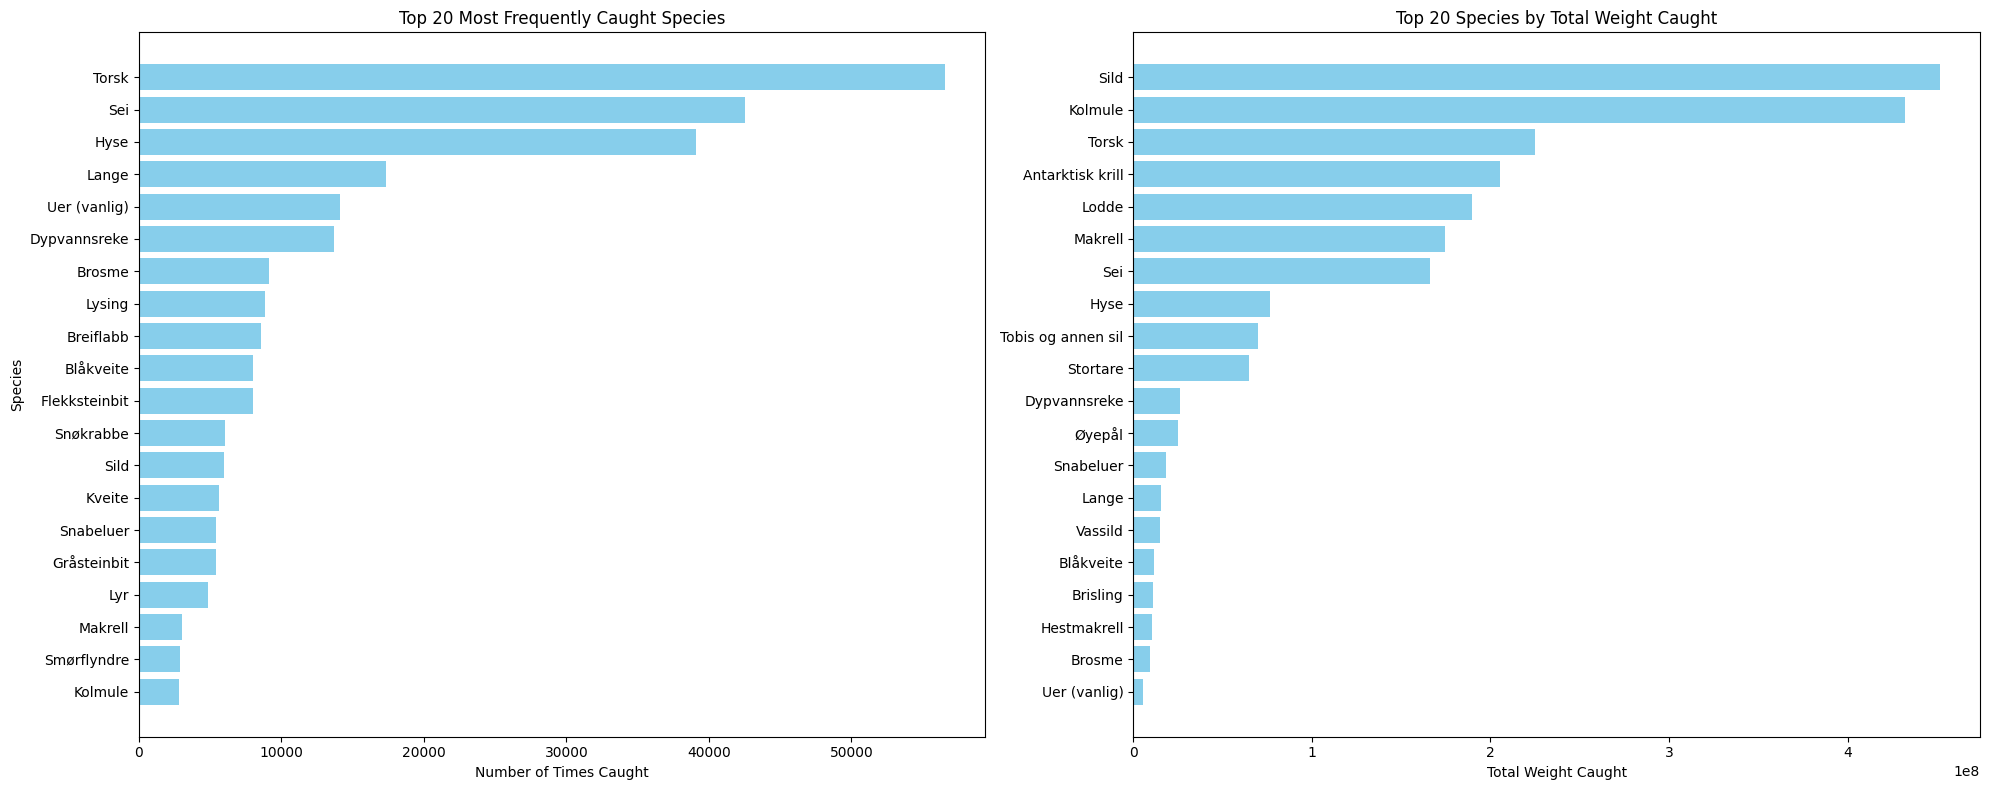

In [19]:
#Top 20 by frequency
count_by_species = df.groupby('Art - FDIR').size().reset_index(name='Counts')
sorted_species_counts = count_by_species.sort_values(by='Counts', ascending=False)
top_20_species_counts = sorted_species_counts.head(20)

#Top 20 by weight
total_weights_by_species = df.groupby('Art - FDIR')['Rundvekt'].sum().reset_index()
sorted_species = total_weights_by_species.sort_values(by='Rundvekt', ascending=False)
top_20_species = sorted_species.head(20)

#plotting top 20 side by side
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

axs[0].barh(top_20_species_counts['Art - FDIR'], top_20_species_counts['Counts'], color='skyblue')
axs[0].set_xlabel('Number of Times Caught')
axs[0].set_ylabel('Species')
axs[0].set_title('Top 20 Most Frequently Caught Species')
axs[0].invert_yaxis()  # Invert y-axis to have the highest values at the top

axs[1].barh(top_20_species['Art - FDIR'], top_20_species['Rundvekt'], color='skyblue')
axs[1].set_title("Top 20 Species by Total Weight Caught")
axs[1].set_xlabel('Total Weight Caught')
axs[1].invert_yaxis()  

plt.tight_layout()
plt.show()


We can here see two neat histograms showing the most caught species by frequency and weight.

Generally we find the same species in both histograms, which implies an correlation between frecuency and quantity caught. There are some exceptions like Kolmule and Sild with high quantity and relatively low frequency.
Since we wish to predict 'Rundvekt', the most caught species in quantity is most relevant. These species will be used for the one-hot-encoding.



Now we create a list with the ten most caught species and use them as features for the dataframe. Then iterate through the rows in the DataFrame and sets boolean values ‘True’ or ‘False’ based on whether the species is in the top ten list or not. 

In [20]:
top_10 = sorted_species_counts.head(10)
top_10_list = top_10['Art - FDIR'].tolist()
print(top_10_list)

for species in top_10_list:
    grouped_df[species] = False

grouped_df["Other"] = False


grouped_df.info()

['Torsk', 'Sei', 'Hyse', 'Lange', 'Uer (vanlig)', 'Dypvannsreke', 'Brosme', 'Lysing', 'Breiflabb', 'Blåkveite']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100079 entries, 0 to 100078
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Starttidspunkt        100079 non-null  datetime64[ns]
 1   Havdybde start        100079 non-null  float64       
 2   Havdybde stopp        100079 non-null  float64       
 3   Startposisjon bredde  100079 non-null  float64       
 4   Stopposisjon bredde   100079 non-null  float64       
 5   Startposisjon lengde  100079 non-null  float64       
 6   Stopposisjon lengde   100079 non-null  float64       
 7   Redskap FAO           100012 non-null  category      
 8   Bredde                99395 non-null   float64       
 9   Fartøylengde          100079 non-null  float64       
 10  Trekkavstand          100064 non-null  float64       
 11  Art -

In [21]:
for index, row in grouped_df.iterrows():
    for item in row['Art - FDIR']:
        # 'item' represents each species in the list
        if item in top_10_list:
            grouped_df.at[index, item] = True
        else:
            grouped_df.at[index, "Other"] = True

Replacing True with 1 and False with 0 to get numerical values.

In [22]:
grouped_df.replace({True: 1, False: 0}, inplace=True)

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/3034783898.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grouped_df.replace({True: 1, False: 0}, inplace=True)


In [23]:
grouped_df.head()

,Starttidspunkt,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Redskap FAO,Bredde,Fartøylengde,...,Sei,Hyse,Lange,Uer (vanlig),Dypvannsreke,Brosme,Lysing,Breiflabb,Blåkveite,Other
0,2017-12-31 00:00:00,-2740.0,-805.0,-60.350,-60.400,-46.133,-46.150,"Flytetrål, otter",19.87,133.88,...,0,0,0,0,0,0,0,0,0,1
1,2017-12-30 23:21:00,-335.0,-334.0,74.885,74.914,16.048,15.969,"Bunntrål, otter",12.60,56.80,...,1,1,0,0,0,0,0,0,1,0
2,2017-12-31 05:48:00,-403.0,-277.0,74.910,74.901,15.868,16.248,"Bunntrål, otter",12.60,56.80,...,1,1,0,0,0,0,0,0,1,1
3,2017-12-31 11:34:00,-346.0,-496.0,74.883,74.924,16.056,15.742,"Bunntrål, otter",12.60,56.80,...,1,1,0,1,0,0,0,0,1,1
4,2017-12-31 17:44:00,-443.0,-358.0,74.931,74.926,15.785,15.894,"Bunntrål, otter",12.60,56.80,...,0,1,0,0,0,0,0,0,0,0


Here you can see that we have successfully added the top 10 species and 'other' to our dataframe, and given a binary value.

Now we remove the column 'Art - FDIR', because it is redundant after we added the top ten species instead.

In [24]:
grouped_df = grouped_df.drop('Art - FDIR', axis=1)
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100079 entries, 0 to 100078
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Starttidspunkt        100079 non-null  datetime64[ns]
 1   Havdybde start        100079 non-null  float64       
 2   Havdybde stopp        100079 non-null  float64       
 3   Startposisjon bredde  100079 non-null  float64       
 4   Stopposisjon bredde   100079 non-null  float64       
 5   Startposisjon lengde  100079 non-null  float64       
 6   Stopposisjon lengde   100079 non-null  float64       
 7   Redskap FAO           100012 non-null  category      
 8   Bredde                99395 non-null   float64       
 9   Fartøylengde          100079 non-null  float64       
 10  Trekkavstand          100064 non-null  float64       
 11  Rundvekt              100079 non-null  float64       
 12  Varighet              100079 non-null  float64       
 13 

## Remove null-values
<a id="Section2.3"></a>


We want to standardise features with missing values to 'NaN', so we can effectively remove all those activities. We did not remove null-values before grouping because we want to eliminate the entire fishing-activity with missing data.

In [25]:
grouped_df.replace({"-":np.nan}, inplace = True)
grouped_df.replace({" ":np.nan}, inplace = True)

In [26]:
grouped_df.isna().sum()

Starttidspunkt            0
Havdybde start            0
Havdybde stopp            0
Startposisjon bredde      0
Stopposisjon bredde       0
Startposisjon lengde      0
Stopposisjon lengde       0
Redskap FAO              67
Bredde                  684
Fartøylengde              0
Trekkavstand             15
Rundvekt                  0
Varighet                  0
Torsk                     0
Sei                       0
Hyse                      0
Lange                     0
Uer (vanlig)              0
Dypvannsreke              0
Brosme                    0
Lysing                    0
Breiflabb                 0
Blåkveite                 0
Other                     0
dtype: int64

There is 759 missing features, and we will remove all those activities so the models don't learn from wrong entries. Removing only the rows and not the features since there is only a few null values.

In [27]:
grouped_df = grouped_df[grouped_df['Redskap FAO'].notnull()]
grouped_df = grouped_df[grouped_df['Bredde'].notnull()]
grouped_df = grouped_df[grouped_df['Trekkavstand'].notnull()]

grouped_df.isna().sum()

Starttidspunkt          0
Havdybde start          0
Havdybde stopp          0
Startposisjon bredde    0
Stopposisjon bredde     0
Startposisjon lengde    0
Stopposisjon lengde     0
Redskap FAO             0
Bredde                  0
Fartøylengde            0
Trekkavstand            0
Rundvekt                0
Varighet                0
Torsk                   0
Sei                     0
Hyse                    0
Lange                   0
Uer (vanlig)            0
Dypvannsreke            0
Brosme                  0
Lysing                  0
Breiflabb               0
Blåkveite               0
Other                   0
dtype: int64

In [28]:
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99313 entries, 0 to 100078
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Starttidspunkt        99313 non-null  datetime64[ns]
 1   Havdybde start        99313 non-null  float64       
 2   Havdybde stopp        99313 non-null  float64       
 3   Startposisjon bredde  99313 non-null  float64       
 4   Stopposisjon bredde   99313 non-null  float64       
 5   Startposisjon lengde  99313 non-null  float64       
 6   Stopposisjon lengde   99313 non-null  float64       
 7   Redskap FAO           99313 non-null  category      
 8   Bredde                99313 non-null  float64       
 9   Fartøylengde          99313 non-null  float64       
 10  Trekkavstand          99313 non-null  float64       
 11  Rundvekt              99313 non-null  float64       
 12  Varighet              99313 non-null  float64       
 13  Torsk               

Since we have removed some rows we reset the index so we don't have indices with no entries.

In [29]:
grouped_df.reset_index(drop=True)

,Starttidspunkt,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Redskap FAO,Bredde,Fartøylengde,...,Sei,Hyse,Lange,Uer (vanlig),Dypvannsreke,Brosme,Lysing,Breiflabb,Blåkveite,Other
0,2017-12-31 00:00:00,-2740.0,-805.0,-60.350,-60.400,-46.133,-46.150,"Flytetrål, otter",19.87,133.88,...,0,0,0,0,0,0,0,0,0,1
1,2017-12-30 23:21:00,-335.0,-334.0,74.885,74.914,16.048,15.969,"Bunntrål, otter",12.60,56.80,...,1,1,0,0,0,0,0,0,1,0
2,2017-12-31 05:48:00,-403.0,-277.0,74.910,74.901,15.868,16.248,"Bunntrål, otter",12.60,56.80,...,1,1,0,0,0,0,0,0,1,1
3,2017-12-31 11:34:00,-346.0,-496.0,74.883,74.924,16.056,15.742,"Bunntrål, otter",12.60,56.80,...,1,1,0,1,0,0,0,0,1,1
4,2017-12-31 17:44:00,-443.0,-358.0,74.931,74.926,15.785,15.894,"Bunntrål, otter",12.60,56.80,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99308,2018-12-31 15:07:00,-191.0,-178.0,70.862,70.877,22.141,22.188,"Bunntrål, otter",10.50,39.79,...,1,1,0,0,0,0,0,0,0,1
99309,2018-12-30 23:20:00,-193.0,-341.0,76.509,76.431,14.295,14.679,"Bunntrål, otter",12.60,57.30,...,1,1,0,1,0,0,0,0,1,1
99310,2018-12-31 05:40:00,-244.0,-299.0,76.385,76.640,14.932,13.642,"Bunntrål, otter",12.60,57.30,...,0,1,0,1,0,0,0,0,1,1
99311,2018-12-31 12:53:00,-280.0,-289.0,76.606,76.899,13.800,12.820,"Bunntrål, otter",12.60,57.30,...,0,1,0,1,0,0,0,0,1,1


# Feature engineering
<a id="Section3"></a>

This is a critical process where we visualize all features in our dataset. We want to search for noise and abnormal values, in addition to remove outliers, so that our model can use the data more correctly and effectively. In addition, we always keep a count on how many values we remove, where we display the remaining value-count after each time any values are removed.

Making a correlation matrix with the dataframes numerical features to check correlation with 'Rundvekt'. This can give us an indication about which features are most relevant.

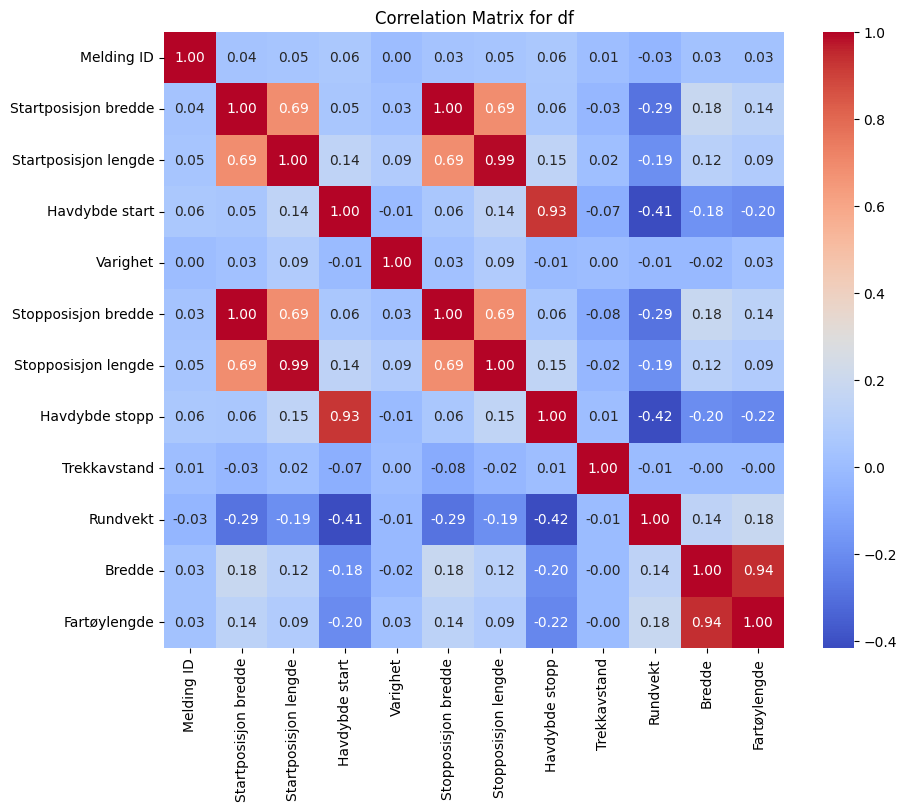

In [30]:
numeric_columns = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for df')
plt.show()

Correlation score goes from -1 to 1, with values close to 0 implying very low correlation.
The correlation matrix shows that correlation between 'Rundvekt' and 'Varighet' and 'Trekkavstand' are very low. So we will start by examinating these features.

Before doing feature engineering we split the dataframe into training and test set. Splitting a dataset into training and test sets helps prevent data leakage by ensuring that the model is evaluated on completely unseen data. This separation helps the model's ability to generalize well to new data, rather than memorizing specific entries from the training set.

<a id="Section3.1"></a>


In [31]:
X = grouped_df.drop('Rundvekt', axis=1)
y = grouped_df['Rundvekt']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(74484, 23)
(24829, 23)
(74484,)
(24829,)


In [32]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74484 entries, 93870 to 15882
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Starttidspunkt        74484 non-null  datetime64[ns]
 1   Havdybde start        74484 non-null  float64       
 2   Havdybde stopp        74484 non-null  float64       
 3   Startposisjon bredde  74484 non-null  float64       
 4   Stopposisjon bredde   74484 non-null  float64       
 5   Startposisjon lengde  74484 non-null  float64       
 6   Stopposisjon lengde   74484 non-null  float64       
 7   Redskap FAO           74484 non-null  category      
 8   Bredde                74484 non-null  float64       
 9   Fartøylengde          74484 non-null  float64       
 10  Trekkavstand          74484 non-null  float64       
 11  Varighet              74484 non-null  float64       
 12  Torsk                 74484 non-null  int64         
 13  Sei              


## Varighet

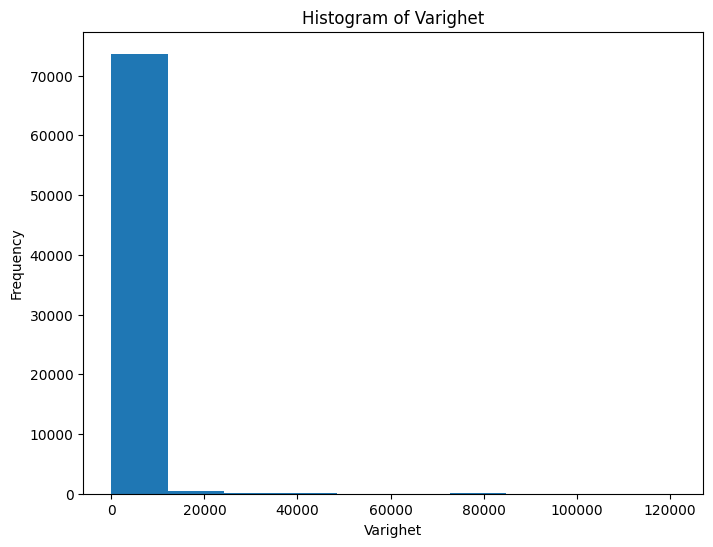

In [33]:

plt.show()
plt.figure(figsize=(8, 6))
plt.hist(X_train['Varighet'], bins=10)
plt.title('Histogram of Varighet')
plt.xlabel('Varighet')
plt.ylabel('Frequency')

plt.show()

Given the very big spread in values in 'Varighet', we will investigate the feature and its values. 

Starting by finding the longest and shortest fishing activity.

In [34]:
max_varighet = X_train['Varighet'].max()
min_varighet = X_train['Varighet'].min()

print(f"Maximal Varighet: {max_varighet} minutes")
print(f"Minimal Varighet: {min_varighet} minutes")

Maximal Varighet: 121140.0 minutes
Minimal Varighet: 0.0 minutes


Finding the top 10 species by average and maximum fishing time. Here we use the original dataframe since we want one entry per species.

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/3495940869.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_durations = df.groupby('Art - FDIR')['Varighet'].mean().reset_index()
/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/3495940869.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_durations = df.groupby('Art - FDIR')['Varighet'].max().reset_index()


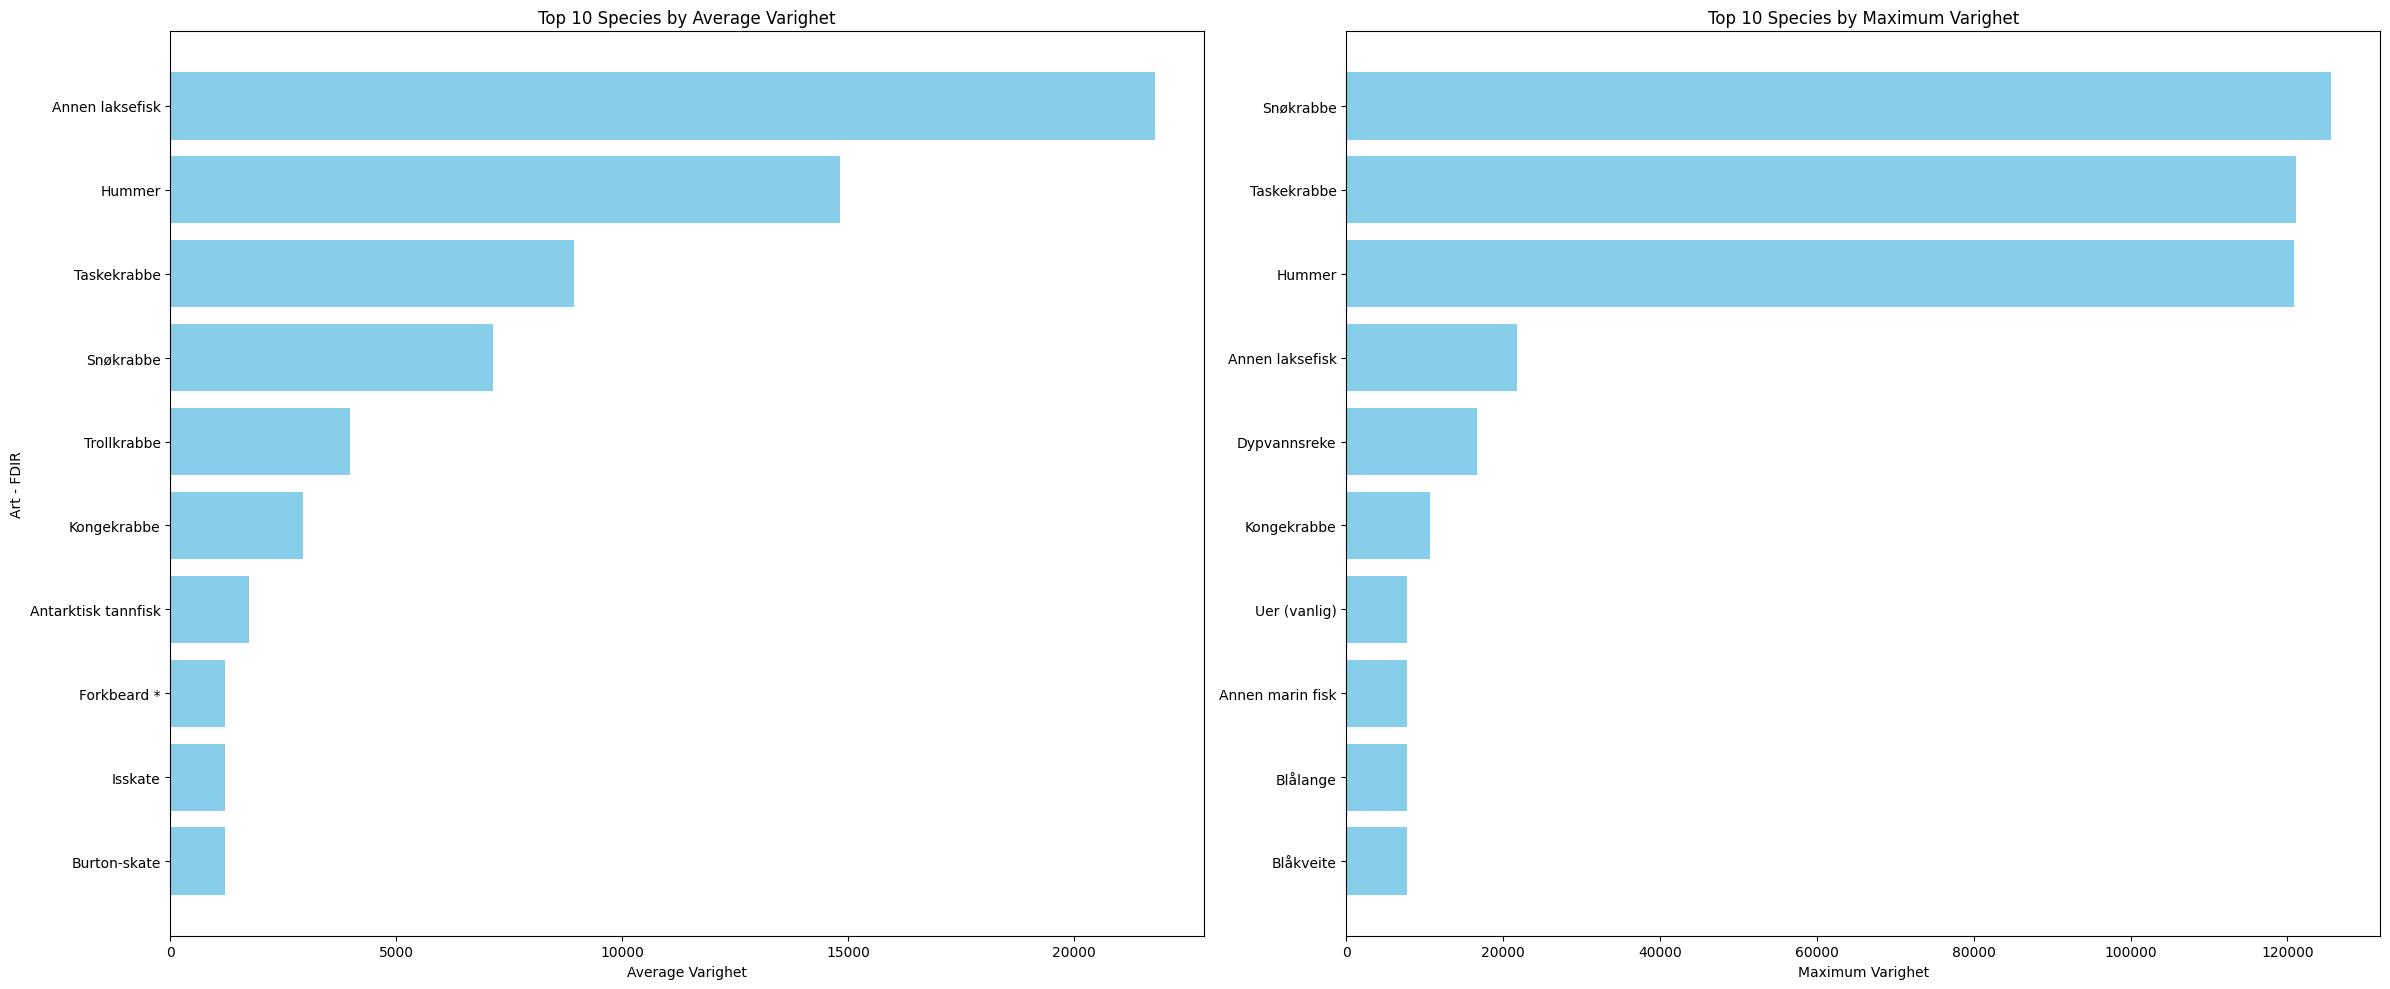

In [35]:
# average durations
average_durations = df.groupby('Art - FDIR')['Varighet'].mean().reset_index()
sorted_durations = average_durations.sort_values(by='Varighet', ascending=False)
top_10_durations = sorted_durations.head(10)

# maximum durations
max_durations = df.groupby('Art - FDIR')['Varighet'].max().reset_index()
sorted_max_durations = max_durations.sort_values(by='Varighet', ascending=False)
top_10_max_durations = sorted_max_durations.head(10)

#plotting side by side
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

axs[0].barh(top_10_durations['Art - FDIR'], top_10_durations['Varighet'], color='skyblue')
axs[0].set_xlabel('Average Varighet')
axs[0].set_ylabel('Art - FDIR')
axs[0].set_title('Top 10 Species by Average Varighet')
axs[0].invert_yaxis()  

axs[1].barh(top_10_max_durations['Art - FDIR'], top_10_max_durations['Varighet'], color='skyblue')
axs[1].set_title("Top 10 Species by Maximum Varighet")
axs[1].set_xlabel('Maximum Varighet')
axs[1].invert_yaxis()  

plt.tight_layout()
plt.show()

We observe that the maximum and average 'Varighet', especially for snøkrabbe, taskekrabbe and lobster, vary significantly. This could be due to several factors, such as bad weather preventing the retrieval of traps.

In [36]:
zero_durations = df[df['Varighet'] == 0]

zero_duration_counts = zero_durations.groupby('Art - FDIR').size().reset_index(name='Count')

sorted_zero_duration_counts = zero_duration_counts.sort_values(by='Count', ascending=False)

print(sorted_zero_duration_counts)

                   Art - FDIR  Count
109                     Torsk   1639
38                       Hyse   1261
22                     Brosme    989
82                        Sei    902
52                      Lange    790
..                        ...    ...
73             Rød kråkebolle      0
72                  Rundskate      0
71         Rognkjeks (felles)      0
70   Reke av  Pandalusslekten      0
61               Mora, uspes.      0

[122 rows x 2 columns]


/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/3370296272.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zero_duration_counts = zero_durations.groupby('Art - FDIR').size().reset_index(name='Count')


'Varighet' has multiple high values and zero values. The spread between 'Varighet' values for the same species is also large. In the correlation matrix we see a correlation of -0.01. Therefore we will remove the entire feature from our dataframe, as it is a lot of noise. 

In [37]:
X_train = X_train.drop(columns=['Varighet'], axis=1)
X_test = X_test.drop(columns=['Varighet'], axis=1)

## Trekkavstand

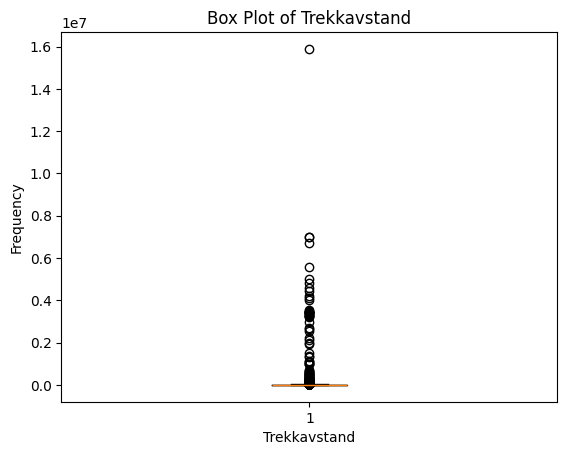

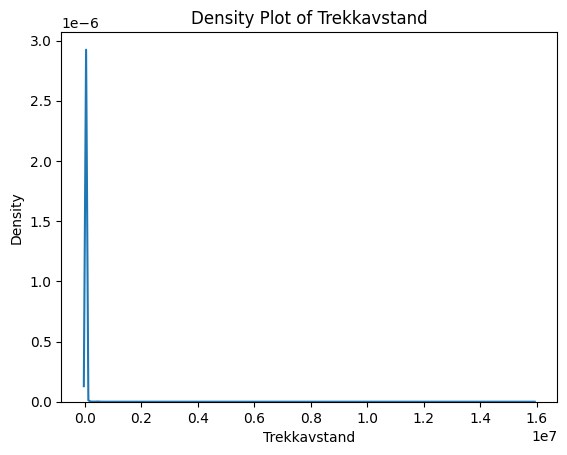

In [38]:
plt.boxplot(X_train['Trekkavstand'])
plt.title('Box Plot of Trekkavstand')
plt.xlabel('Trekkavstand')
plt.ylabel('Frequency')
plt.show()

sns.kdeplot(X_train['Trekkavstand'])
plt.title('Density Plot of Trekkavstand')
plt.xlabel('Trekkavstand')
plt.ylabel('Density')
plt.show()

The plot shows a very big spread in values with one clear density center.

Given the low correlation score and abundance of datapoints far from the density center we chose to remove the entire feature. In addition we have start and stop position features giving the same information.

In [39]:
X_train = X_train.drop(columns=['Trekkavstand'], axis=1)
X_test = X_test.drop(columns=['Trekkavstand'], axis=1)

In [40]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74484 entries, 93870 to 15882
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Starttidspunkt        74484 non-null  datetime64[ns]
 1   Havdybde start        74484 non-null  float64       
 2   Havdybde stopp        74484 non-null  float64       
 3   Startposisjon bredde  74484 non-null  float64       
 4   Stopposisjon bredde   74484 non-null  float64       
 5   Startposisjon lengde  74484 non-null  float64       
 6   Stopposisjon lengde   74484 non-null  float64       
 7   Redskap FAO           74484 non-null  category      
 8   Bredde                74484 non-null  float64       
 9   Fartøylengde          74484 non-null  float64       
 10  Torsk                 74484 non-null  int64         
 11  Sei                   74484 non-null  int64         
 12  Hyse                  74484 non-null  int64         
 13  Lange            

## Position

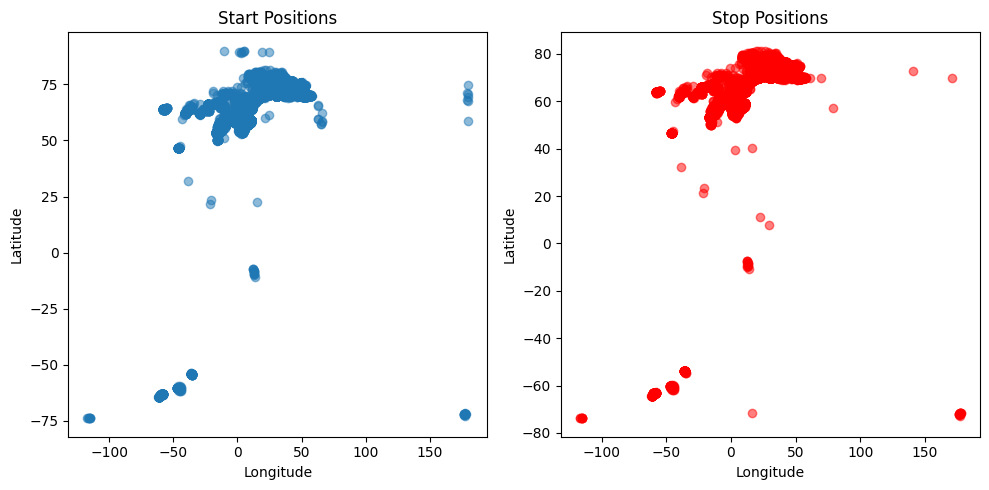

In [41]:
# Plotting starting positions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train['Startposisjon lengde'], X_train['Startposisjon bredde'], alpha=0.5)
plt.title('Start Positions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Plotting stopping positions
plt.subplot(1, 2, 2)
plt.scatter(X_train['Stopposisjon lengde'], X_train['Stopposisjon bredde'], alpha=0.5, color='red')
plt.title('Stop Positions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

Removing datapoints that is far from Norway, because we want to focus on activities around the norwegian coast.

In [42]:
# Filter rows where both start and stop positions are within the specified latitude and longitude ranges
indices_to_keep_train = X_train[
    (X_train['Startposisjon bredde'] >= 48) & (X_train['Startposisjon bredde'] <= 85) &
    (X_train['Stopposisjon bredde'] >= 48) & (X_train['Stopposisjon bredde'] <= 85) &
    (X_train['Startposisjon lengde'] >= -20) & (X_train['Startposisjon lengde'] <= 53) &
    (X_train['Stopposisjon lengde'] >= -20) & (X_train['Stopposisjon lengde'] <= 53)
    ].index

y_train = y_train.loc[indices_to_keep_train]
X_train = X_train.loc[indices_to_keep_train]

indices_to_keep_test = X_test[
    (X_test['Startposisjon bredde'] >= 48) & (X_test['Startposisjon bredde'] <= 85) &
    (X_test['Stopposisjon bredde'] >= 48) & (X_test['Stopposisjon bredde'] <= 85) &
    (X_test['Startposisjon lengde'] >= -20) & (X_test['Startposisjon lengde'] <= 53) &
    (X_test['Stopposisjon lengde'] >= -20) & (X_test['Stopposisjon lengde'] <= 53)
    ].index

X_test = X_test.loc[indices_to_keep_test]
y_test = y_test.loc[indices_to_keep_test]

In [43]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73202 entries, 93870 to 15882
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Starttidspunkt        73202 non-null  datetime64[ns]
 1   Havdybde start        73202 non-null  float64       
 2   Havdybde stopp        73202 non-null  float64       
 3   Startposisjon bredde  73202 non-null  float64       
 4   Stopposisjon bredde   73202 non-null  float64       
 5   Startposisjon lengde  73202 non-null  float64       
 6   Stopposisjon lengde   73202 non-null  float64       
 7   Redskap FAO           73202 non-null  category      
 8   Bredde                73202 non-null  float64       
 9   Fartøylengde          73202 non-null  float64       
 10  Torsk                 73202 non-null  int64         
 11  Sei                   73202 non-null  int64         
 12  Hyse                  73202 non-null  int64         
 13  Lange            

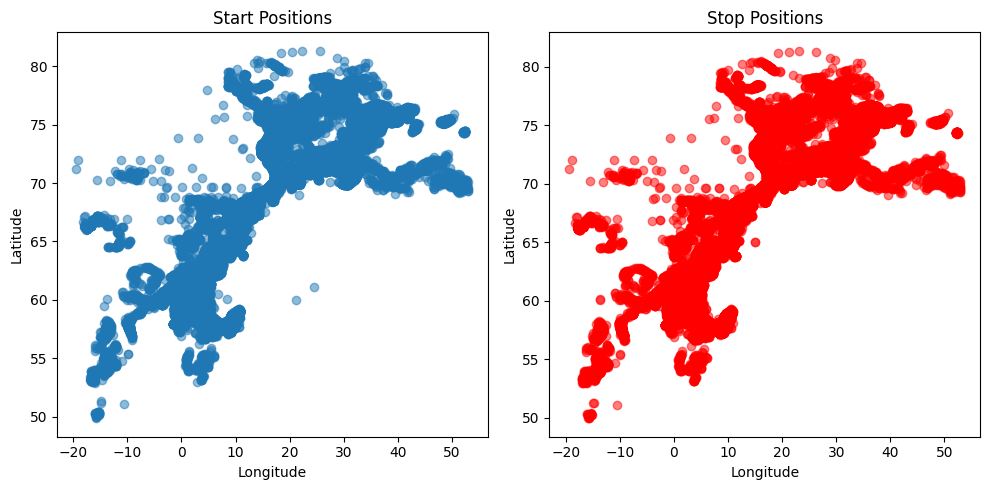

In [44]:
# Plotting starting positions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train['Startposisjon lengde'], X_train['Startposisjon bredde'], alpha=0.5)
plt.title('Start Positions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Plotting stopping positions
plt.subplot(1, 2, 2)
plt.scatter(X_train['Stopposisjon lengde'], X_train['Stopposisjon bredde'], alpha=0.5, color='red')
plt.title('Stop Positions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

The datapoints are now more concentrated and relevant, resembling the shape of the norwegian coastline. Three datapoints on the mainland may be due to registration errors or their location within fjords. We have decided to retain this configuration.

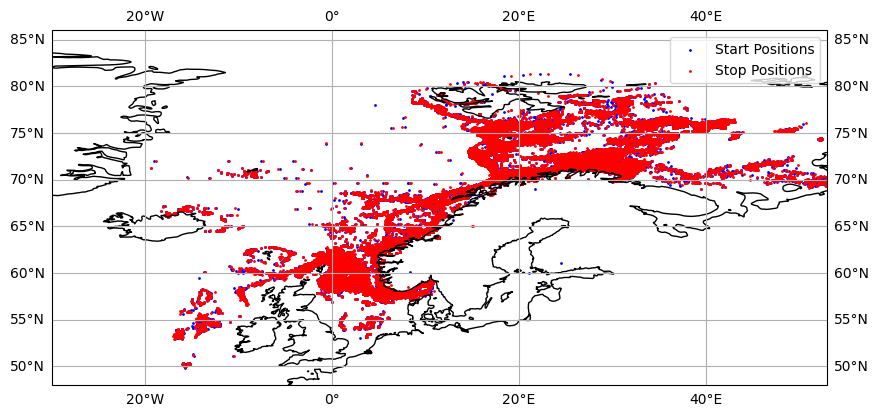

In [45]:
fig = plt.figure(figsize=(10, 5))

ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-30, 53, 48, 86], crs=ccrs.PlateCarree()) 

ax.coastlines()

ax.scatter(X_train['Startposisjon lengde'], X_train['Startposisjon bredde'], s=1, color='blue', transform=ccrs.PlateCarree(), label='Start Positions')

ax.scatter(X_train['Stopposisjon lengde'], X_train['Stopposisjon bredde'], s=1, color='red', transform=ccrs.PlateCarree(), label='Stop Positions')

ax.legend()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.show()

This map clearly shows the positions are focused around Norway.


## Havdybde
<a id="#Havdybde"></a>

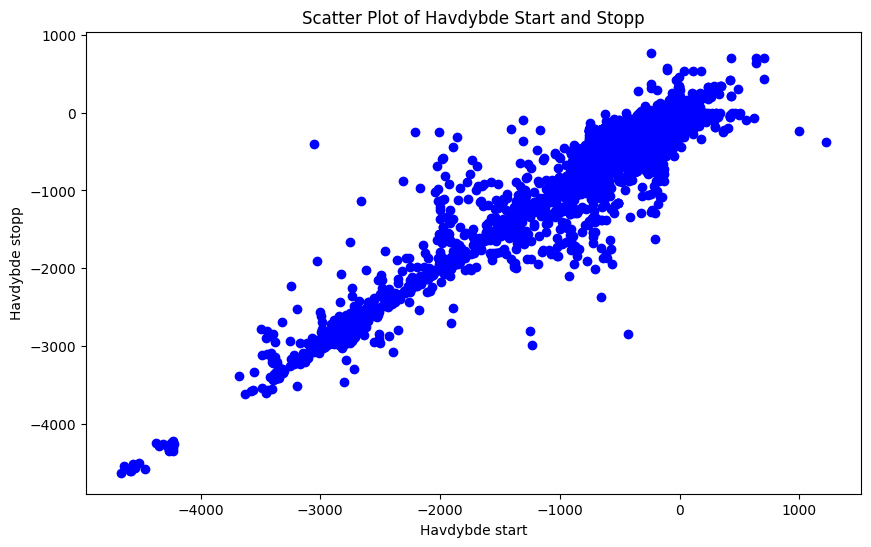

In [46]:
# Plotting the distribution of 'Havdybde start' and 'Havdybde stopp'
plt.figure(figsize=(10, 6))
plt.scatter(X_train['Havdybde start'], X_train['Havdybde stopp'], c='blue')
plt.title('Scatter Plot of Havdybde Start and Stopp')
plt.xlabel('Havdybde start')
plt.ylabel('Havdybde stopp')
plt.show()

As we can see from the scatterplot there are some nonsensical postivive values. We're assuming that they're just wrongly documented as positives, so the points are just missing a minus sign in front of them. 
We assume that 'Havdybde' is measured in distance to seafloor, and not the depth of the fishing activity, so we will keep all the values.

In [47]:
#Changing the negative values to positive
X_train['Havdybde start'] = X_train['Havdybde start'].apply(lambda x: -x if x > 0 else x)
X_train['Havdybde stopp'] = X_train['Havdybde stopp'].apply(lambda x: -x if x > 0 else x)
X_test['Havdybde start'] = X_test['Havdybde start'].apply(lambda x: -x if x > 0 else x)
X_test['Havdybde stopp'] = X_test['Havdybde stopp'].apply(lambda x: -x if x > 0 else x)

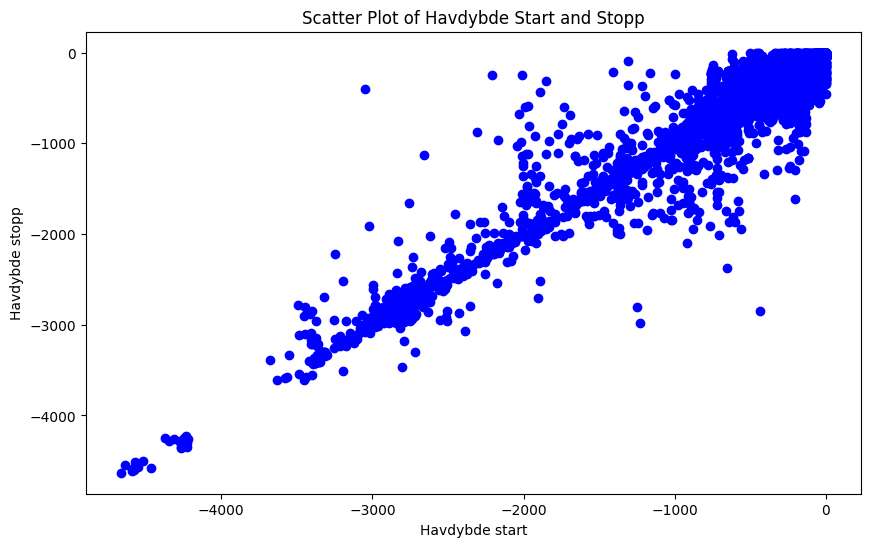

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train['Havdybde start'], X_train['Havdybde stopp'], c='blue')
plt.title('Scatter Plot of Havdybde Start and Stopp')
plt.xlabel('Havdybde start')
plt.ylabel('Havdybde stopp')
plt.show()

There is still some points here that can be looked at as outliers, since their start and stop positions are so different. But we conclude that they make sense, since ocean depths can change rapidly. 

## Bredde and Fartøylengde

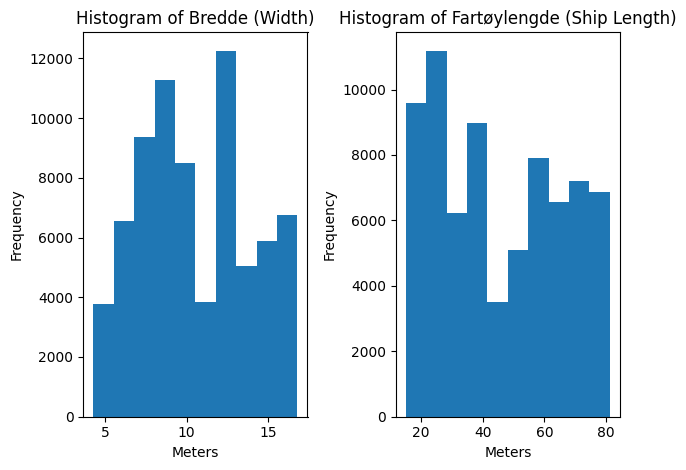

In [49]:
# Histogram for 'Bredde'
plt.subplot(1, 2, 1)
plt.hist(X_train['Bredde'], bins=10)
plt.title('Histogram of Bredde (Width)')
plt.xlabel('Meters')
plt.ylabel('Frequency')

# Histogram for 'Fartøyslengde'
plt.subplot(1, 2, 2)
plt.hist(X_train['Fartøylengde'], bins=10)
plt.title('Histogram of Fartøylengde (Ship Length)')
plt.xlabel('Meters')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

There are no outliers, so we don't have to remove any datapoints.

We reset indices after removing data, to ensure all indices have values.

In [50]:
X_train.reset_index(drop=True)
y_train.reset_index(drop=True)
X_test.reset_index(drop=True)
y_test.reset_index(drop=True)

0         7542.0
1         5327.0
2        17500.0
3         8089.0
4          500.0
          ...   
24415        0.0
24416     4942.0
24417     4000.0
24418    10561.0
24419      153.0
Name: Rundvekt, Length: 24420, dtype: float64

In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73202 entries, 93870 to 15882
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Starttidspunkt        73202 non-null  datetime64[ns]
 1   Havdybde start        73202 non-null  float64       
 2   Havdybde stopp        73202 non-null  float64       
 3   Startposisjon bredde  73202 non-null  float64       
 4   Stopposisjon bredde   73202 non-null  float64       
 5   Startposisjon lengde  73202 non-null  float64       
 6   Stopposisjon lengde   73202 non-null  float64       
 7   Redskap FAO           73202 non-null  category      
 8   Bredde                73202 non-null  float64       
 9   Fartøylengde          73202 non-null  float64       
 10  Torsk                 73202 non-null  int64         
 11  Sei                   73202 non-null  int64         
 12  Hyse                  73202 non-null  int64         
 13  Lange            

## One-hot encoding seasons

<a id="Section3.2"></a>

We one-hot encode seasons to simplify the feature space and to identify any potential seasonal patterns in the data. This helps the model generalize better since it only looks at four seasons instead of spesific dates('Starttidspunkt'). One downside to this approach is that fishing-activities around seasonal shifts are weighted different.

In [52]:
#changing for x_train
X_train['Month'] = X_train['Starttidspunkt'].dt.month
    
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


X_train['Season'] = X_train['Month'].apply(month_to_season)
one_hot_encoded = pd.get_dummies(X_train['Season'])
X_train = pd.concat([X_train, one_hot_encoded], axis=1)
X_train = X_train.drop(['Month', 'Season'], axis=1)
X_train.replace({True: 1, False: 0}, inplace=True)

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/1804698724.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train.replace({True: 1, False: 0}, inplace=True)


In [53]:
#Same for X_test
X_test['Month'] = X_test['Starttidspunkt'].dt.month

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

X_test['Season'] = X_test['Month'].apply(month_to_season)
one_hot_encoded = pd.get_dummies(X_test['Season'])
X_test = pd.concat([X_test, one_hot_encoded], axis=1)
X_test = X_test.drop(['Month', 'Season'], axis=1)
X_test.replace({True: 1, False: 0}, inplace=True)

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/2687408124.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.replace({True: 1, False: 0}, inplace=True)


In [54]:
X_train.head()

,Starttidspunkt,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Redskap FAO,Bredde,Fartøylengde,...,Dypvannsreke,Brosme,Lysing,Breiflabb,Blåkveite,Other,Autumn,Spring,Summer,Winter
93870,2018-11-25 17:08:00,-214.0,-226.0,73.180,73.115,33.173,32.945,"Bunntrål, otter",15.0,65.00,...,0,0,0,0,0,1,1,0,0,0
41698,2018-05-18 18:08:00,-103.0,-171.0,57.867,58.167,5.300,4.517,"Bunntrål, otter",9.5,35.00,...,0,0,1,1,0,1,0,1,0,0
48053,2018-06-06 13:52:00,-205.0,-196.0,77.184,77.169,27.596,27.589,"Bunntrål, reke",16.0,74.00,...,1,0,0,0,0,0,0,0,1,0
80888,2018-10-08 10:23:00,-133.0,-117.0,74.262,74.252,20.517,20.342,"Bunntrål, otter",14.0,66.28,...,0,0,0,0,0,0,1,0,0,0
8463,2018-01-17 18:06:00,-266.0,-267.0,76.234,76.238,37.226,37.352,Teiner,11.2,49.95,...,0,0,0,0,0,1,0,0,0,1


Now we can remove 'Starttidspunkt' since we have this data saved as one-hot-encoded seasons.

In [55]:
X_train = X_train.drop(columns=['Starttidspunkt'], axis=1)
X_test = X_test.drop(columns=['Starttidspunkt'], axis=1)
X_train.head()

,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Redskap FAO,Bredde,Fartøylengde,Torsk,...,Dypvannsreke,Brosme,Lysing,Breiflabb,Blåkveite,Other,Autumn,Spring,Summer,Winter
93870,-214.0,-226.0,73.180,73.115,33.173,32.945,"Bunntrål, otter",15.0,65.00,1,...,0,0,0,0,0,1,1,0,0,0
41698,-103.0,-171.0,57.867,58.167,5.300,4.517,"Bunntrål, otter",9.5,35.00,1,...,0,0,1,1,0,1,0,1,0,0
48053,-205.0,-196.0,77.184,77.169,27.596,27.589,"Bunntrål, reke",16.0,74.00,0,...,1,0,0,0,0,0,0,0,1,0
80888,-133.0,-117.0,74.262,74.252,20.517,20.342,"Bunntrål, otter",14.0,66.28,1,...,0,0,0,0,0,0,1,0,0,0
8463,-266.0,-267.0,76.234,76.238,37.226,37.352,Teiner,11.2,49.95,0,...,0,0,0,0,0,1,0,0,0,1


## Season correlation

We are now going to make three different graphs checking average catch, total weight and number of activities per season.
We're doing this to see if there is any correlation between seasons and fish catch, if not we might aswell remove the whole feature.

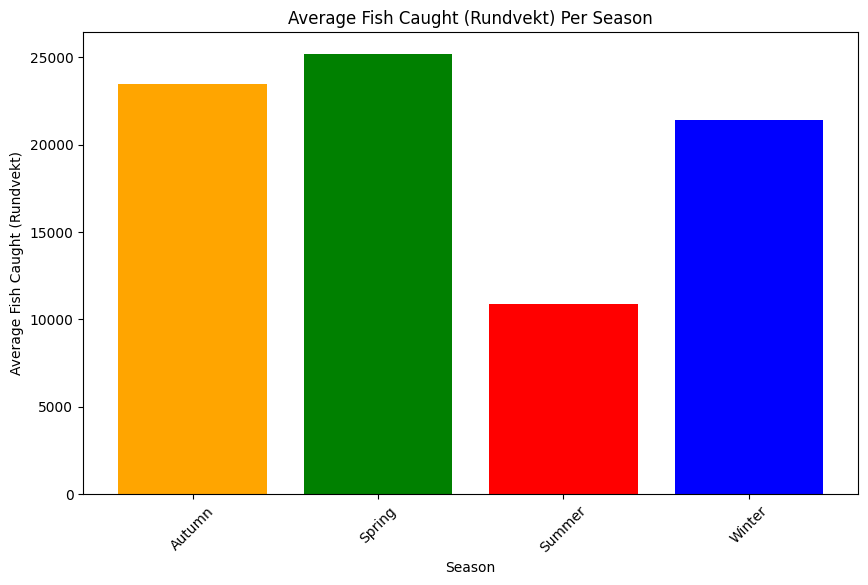

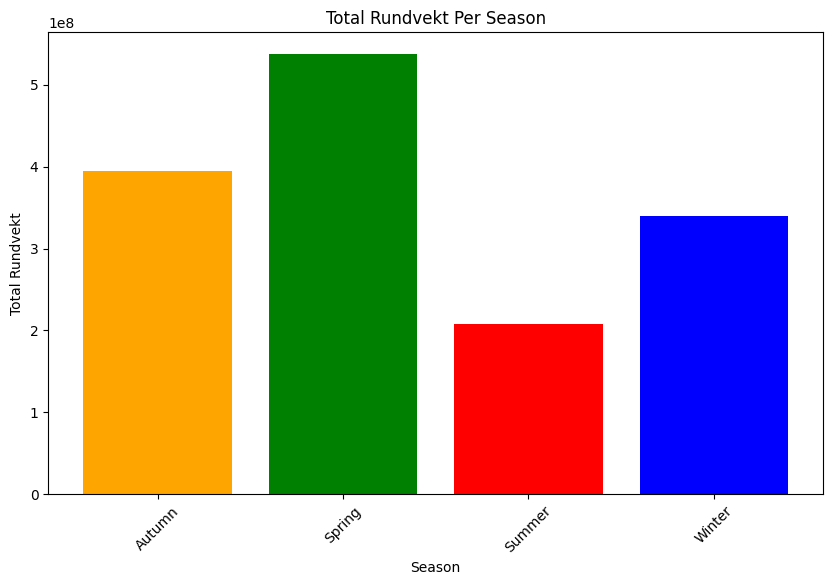

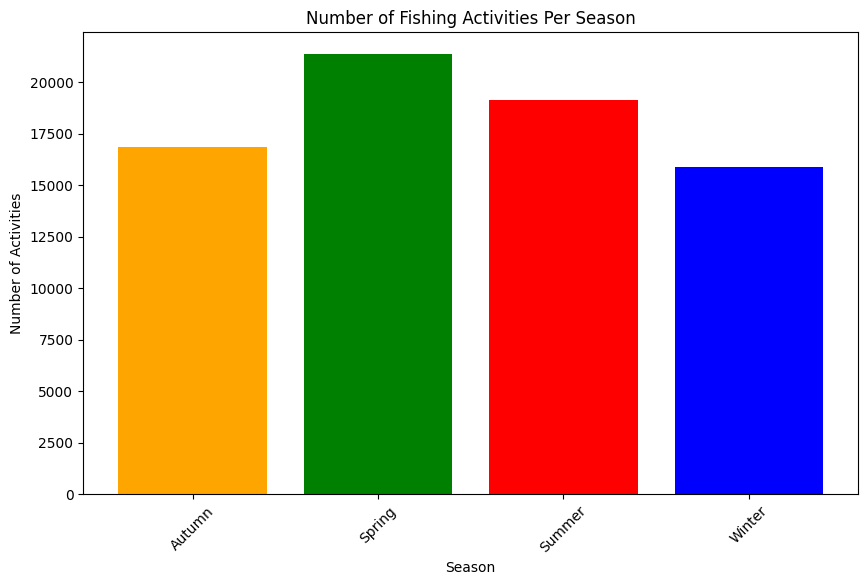

In [56]:

season_averages = {}
season_totals = {}
season_columns = ['Autumn', 'Spring', 'Summer', 'Winter']

for season in season_columns:
    season_indices = X_train[X_train[season] == 1].index
    
    season_rundvekt_values = y_train.loc[season_indices]
    
    average_rundvekt = season_rundvekt_values.mean() if not season_rundvekt_values.empty else 0
    total_rundvekt = season_rundvekt_values.sum() if not season_rundvekt_values.empty else 0
    
    season_averages[season] = average_rundvekt
    season_totals[season] = total_rundvekt

def plot_season_data(data, title, ylabel):
    
    seasons = [season for season in data.keys()]
    values = list(data.values())
    
    
    plt.figure(figsize=(10, 6))
    plt.bar(seasons, values, color=['orange', 'green', 'red', 'blue'])
    plt.title(title)
    plt.xlabel('Season')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)  
    plt.show()

plot_season_data(season_averages, 'Average Fish Caught (Rundvekt) Per Season', 'Average Fish Caught (Rundvekt)')
plot_season_data(season_totals, 'Total Rundvekt Per Season', 'Total Rundvekt')
plot_season_data({season: X_train[X_train[season] == 1].shape[0] for season in season_columns}, 'Number of Fishing Activities Per Season', 'Number of Activities')

The number of fishing activities is pretty stable throughout the year, with a little more activity during spring, but the amount of fish caught is much more varied. We can see that the average amount of fish caught is highest during the autumn, followed by spring. While the total catch is highest during springtime. So we can conclude that autumn and spring is the best seasons to fish, followed by winter and summer which is by far the worst. The seasonal differences can be due to what type of fish that is best to fish at different times. These differences will affect our models, so will keep the one-hot-encoded features in our dataset.

## One-hot encoding 'Redskap FAO'
<a id="Section3.3"></a>

'Redskap FAO' is a categorical value with many different categories. Therefore we want to reduce the number of categories using mapping and one-hot-encoding to help the models perform better. 

In [57]:
unique_redskap = X_train['Redskap FAO'].nunique()

print(f"Number of unique 'Redskap FAO': {unique_redskap}")

Number of unique 'Redskap FAO': 29


A lot of the gear is similiar, so they will be grouped together to simplify the feature space.

In [58]:
print("Unique values before simplification:")
print(X_train['Redskap FAO'].value_counts())

Unique values before simplification:
Redskap FAO
Bunntrål, otter                           26268
Snurrevad, skotsk                         10354
Teiner                                     5007
Bunntrål, reke                             4487
Snurpenot/ringnot, et fartøy               4357
Snurrevad                                  4144
Andre liner                                3519
Setteline                                  2684
Gillnets and entangling nets (unspec)*     2154
Snurpenot/ringnot, to fartøy               1752
Bunntrål (uspes)                           1663
Snurpenot/ringnot                          1338
Flytetrål, otter                           1025
Udefinert garn                              831
Bunntrål, par                               736
Flytetrål, uspesifisert                     695
Flytetrål, par                              537
Harpun,div.                                 370
Otter dobbeltrål                            361
Flytetrål, reke                        

Mapping generalizes different types of gear to more general names to reduce number of different gears.

In [59]:
#Defined mapping for the different values
redskap_mapping = {
    "Bunntrål, otter": "Bunntrål",
    "Bunntrål, reke": "Bunntrål",
    "Bunntrål (uspes)": "Bunntrål",
    "Bunntrål, par": "Bunntrål",

    "Flytetrål, otter": "Flytetrål",
    "Flytetrål, uspesifisert": "Flytetrål",
    "Flytetrål, par": "Flytetrål",
    "Flytetrål, reke": "Flytetrål",

    "Annen trål (udefinert)": "Annen trål",
    "Udefinert trål": "Annen trål",
    "Otter dobbeltrål": "Dobbeltrål",
    "Partrål, uspesifisert": "Partrål",

    "Snurrevad": "Snurrevad",  
    "Snurrevad, skotsk": "Snurrevad",
    "Snurrevad, dansk": "Snurrevad",
    "Snurpenot/ringnot": "Snurpenot/ringnot",
    "Snurpenot/ringnot, et fartøy": "Snurpenot/ringnot",
    "Snurpenot/ringnot, to fartøy": "Snurpenot/ringnot",

    "Gillnets and entangling nets (unspec)*": "Gillnets and entangling nets",
    "Encircling gillnets*": "Gillnets and entangling nets",
    "Juksa/pilk, manuell": "Juksa/pilk",
    "Dorg/harp/snik": "Dorg/harp/snik", 
    "Udefinert garn": "Garn",
    "Harpun,div.": "Harpun",
    "Boat /vessel seines -Pair seines": "Boat seines",
    "Andre liner": "Andre liner",
    "Setteline": "Setteline",
    "Teiner": "Teiner",
}

# Use the mapping to alter the Redskap FAO values
X_train['Redskap FAO'] = X_train['Redskap FAO'].replace(redskap_mapping)
X_test['Redskap FAO'] = X_test['Redskap FAO'].replace(redskap_mapping)

# Remove undused categories
X_train['Redskap FAO'] = X_train['Redskap FAO'].cat.remove_unused_categories()
X_test['Redskap FAO'] = X_test['Redskap FAO'].cat.remove_unused_categories()

print("\nUnique values after simplification:")
print(X_train['Redskap FAO'].value_counts())


Unique values after simplification:
Redskap FAO
Bunntrål                        33154
Snurrevad                       14523
Snurpenot/ringnot                7447
Teiner                           5007
Andre liner                      3519
Setteline                        2684
Flytetrål                        2584
Gillnets and entangling nets     2208
Garn                              831
Harpun                            370
Dobbeltrål                        361
Boat seines                       190
Settegarn                         138
Annen trål                         89
Partrål                            73
Dorg/harp/snik                     12
Juksa/pilk                         12
Name: count, dtype: int64


/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/1013412648.py:38: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X_train['Redskap FAO'] = X_train['Redskap FAO'].replace(redskap_mapping)
/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/1013412648.py:39: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X_test['Redskap FAO'] = X_test['Redskap FAO'].replace(redskap_mapping)


In [60]:
unique_redskap = X_train['Redskap FAO'].nunique()

print(f"Number of unique 'Redskap FAO': {unique_redskap}")

Number of unique 'Redskap FAO': 17


After reducing from 29 to 17 values we one-hot-encode.

In [61]:
#Doing one-hot-encoding for training set
dummies = pd.get_dummies(X_train['Redskap FAO'])
X_train_dropped = X_train.drop('Redskap FAO', axis=1)
X_train = pd.concat([X_train_dropped, dummies], axis=1)

X_train.replace({True: 1, False: 0}, inplace=True)

X_train.head()

/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/6575627.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train.replace({True: 1, False: 0}, inplace=True)


,Havdybde start,Havdybde stopp,Startposisjon bredde,Stopposisjon bredde,Startposisjon lengde,Stopposisjon lengde,Bredde,Fartøylengde,Torsk,Sei,...,Harpun,Juksa/pilk,Dobbeltrål,Partrål,Settegarn,Setteline,Snurpenot/ringnot,Snurrevad,Teiner,Garn
93870,-214.0,-226.0,73.180,73.115,33.173,32.945,15.0,65.00,1,0,...,0,0,0,0,0,0,0,0,0,0
41698,-103.0,-171.0,57.867,58.167,5.300,4.517,9.5,35.00,1,1,...,0,0,0,0,0,0,0,0,0,0
48053,-205.0,-196.0,77.184,77.169,27.596,27.589,16.0,74.00,0,0,...,0,0,0,0,0,0,0,0,0,0
80888,-133.0,-117.0,74.262,74.252,20.517,20.342,14.0,66.28,1,0,...,0,0,0,0,0,0,0,0,0,0
8463,-266.0,-267.0,76.234,76.238,37.226,37.352,11.2,49.95,0,0,...,0,0,0,0,0,0,0,0,1,0


In [62]:
#Doing one-hot-encoding for test set
dummies = pd.get_dummies(X_test['Redskap FAO'])
X_test_dropped = X_test.drop('Redskap FAO', axis=1)
X_test = pd.concat([X_test_dropped, dummies], axis=1)
X_test.replace({True: 1, False: 0}, inplace=True)


/var/folders/wv/9r_x12z117g9dhzkqhl5gs0c0000gn/T/ipykernel_6675/1019253982.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.replace({True: 1, False: 0}, inplace=True)


## Target value
<a id="Section3.4"></a>

The last thing we want to do before initializing models is having a look at the target value 'Rundvekt'. Checking for outliers and potential noise that can impact our models precision.

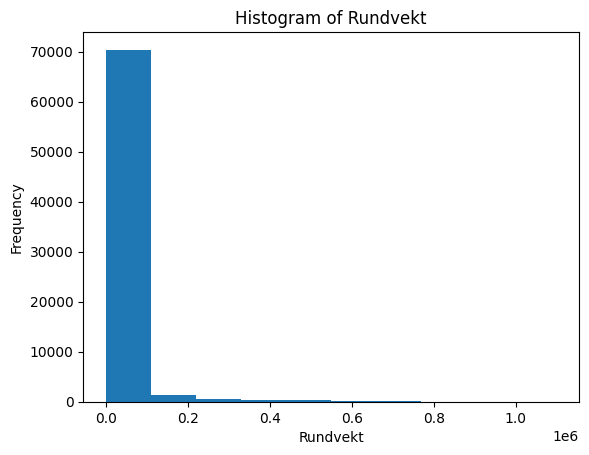

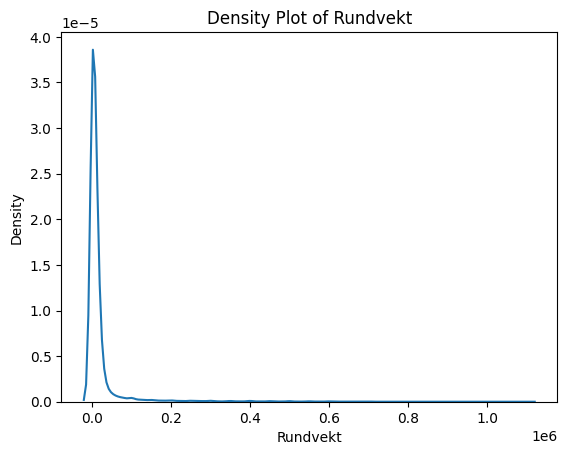

In [63]:
plt.hist(y_train, bins=10)
plt.xlabel('Rundvekt')
plt.ylabel('Frequency')
plt.title('Histogram of Rundvekt')
plt.show()

sns.kdeplot(y_train)
plt.title('Density Plot of Rundvekt')
plt.xlabel('Rundvekt')
plt.ylabel('Density')
plt.show()

In [64]:
zero_count = (y_train == 0).sum()
print(f"Number of zero values: {zero_count}")

Number of zero values: 3578


We can see a clear density center and only a few values larger than 200,000. Therefore we remove all values above this threshold to reduce noise. We also checked for zero values and will remove these aswell.

In [65]:
indices_to_keep_train = y_train[
    (y_train <= 200000) & (y_train > 0)
    ].index

y_train = y_train.loc[indices_to_keep_train]
X_train = X_train.loc[indices_to_keep_train]

indices_to_keep_test = y_test[
    (y_test <= 200000) & (y_test > 0)
    ].index

X_test = X_test.loc[indices_to_keep_test]
y_test = y_test.loc[indices_to_keep_test]

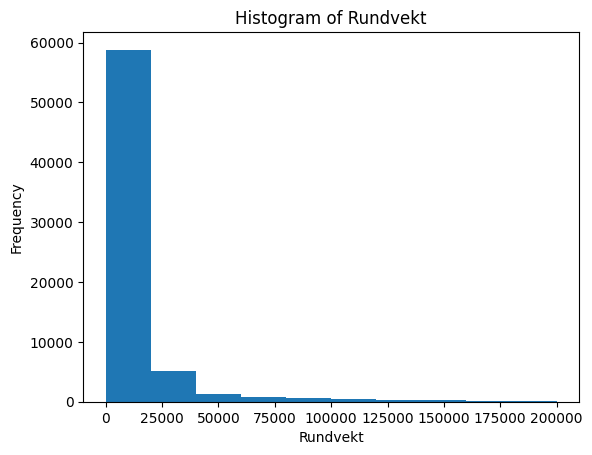

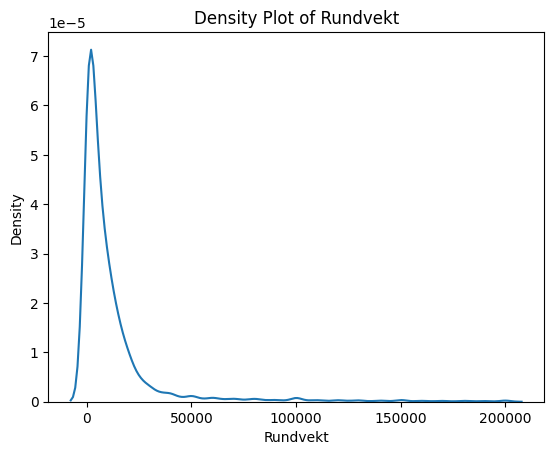

In [66]:
plt.hist(y_train, bins=10)
plt.xlabel('Rundvekt')
plt.ylabel('Frequency')
plt.title('Histogram of Rundvekt')
plt.show()

sns.kdeplot(y_train)
plt.title('Density Plot of Rundvekt')
plt.xlabel('Rundvekt')
plt.ylabel('Density')
plt.show()

In [67]:
zero_count = (y_train == 0).sum()
print(f"Number of zero values: {zero_count}")

Number of zero values: 0


In [68]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67968 entries, 93870 to 15882
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Havdybde start                67968 non-null  float64
 1   Havdybde stopp                67968 non-null  float64
 2   Startposisjon bredde          67968 non-null  float64
 3   Stopposisjon bredde           67968 non-null  float64
 4   Startposisjon lengde          67968 non-null  float64
 5   Stopposisjon lengde           67968 non-null  float64
 6   Bredde                        67968 non-null  float64
 7   Fartøylengde                  67968 non-null  float64
 8   Torsk                         67968 non-null  int64  
 9   Sei                           67968 non-null  int64  
 10  Hyse                          67968 non-null  int64  
 11  Lange                         67968 non-null  int64  
 12  Uer (vanlig)                  67968 non-null  int64  
 13  Dy

In [69]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22675 entries, 14420 to 38433
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Havdybde start                22675 non-null  float64
 1   Havdybde stopp                22675 non-null  float64
 2   Startposisjon bredde          22675 non-null  float64
 3   Stopposisjon bredde           22675 non-null  float64
 4   Startposisjon lengde          22675 non-null  float64
 5   Stopposisjon lengde           22675 non-null  float64
 6   Bredde                        22675 non-null  float64
 7   Fartøylengde                  22675 non-null  float64
 8   Torsk                         22675 non-null  int64  
 9   Sei                           22675 non-null  int64  
 10  Hyse                          22675 non-null  int64  
 11  Lange                         22675 non-null  int64  
 12  Uer (vanlig)                  22675 non-null  int64  
 13  Dy

Checking that the amount of rows and columns in the train and test set match up and make sense after all the data proccesing.

In [70]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(67968, 40)
(67968,)
(22675, 40)
(22675,)


<a id="Section4"></a>
# Machine Learning Models

We are now pleased with the data preprocessing and will start making models. We will make tree based models, linear models, one deep learning and one clustering model. We intend to train the models using training data. Then we want to evaluate the model's performance on both the training- and an independent validation set, to check for overfitting and to estimate how the model will perform on unseen data.

First we split the training set into a new training and validation set to use when implementing the models. This helps us evaluate the models before using the original test set to check the final performance.

In [71]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=42)

<a id="Section4.1"></a>
## Decision tree regressor

Decision Trees might have a tendency to overfit and be sensitive to small changes in the data, but by implementing ensemble methods like Random Forests Trees and Gradient Boosting Regressor, it can build upon the strenghts of individual decision trees to improve prediction accuracy and stability.

In [72]:
decisiontreeregressor = DecisionTreeRegressor(random_state = 42)
decisiontreeregressor.fit(X_train, y_train)
decisiontreeregressor_train_score = decisiontreeregressor.score(X_train, y_train)
decisiontreeregressor_val_score = decisiontreeregressor.score(X_val, y_val)
print(f"Accuracy on training set: {decisiontreeregressor_train_score}")
print(f"Accuracy on validation set: {decisiontreeregressor_val_score}")

Accuracy on training set: 0.9990881308815162
Accuracy on validation set: 0.43447745128461734


The score on the initial DecisionTreeRegressor indicates a horendous overfit.
The max depth of a decision tree refers to the maximum number of levels the tree can have from its root to the furthest leaf. The default max_depth is None, meaning the nodes will expand far. A deep tree can lead to a complex model that overfits. We've tried a few different values for max_depth and 7 is the best.

In [73]:
decisiontreeregressor5 = DecisionTreeRegressor(max_depth=7, random_state = 42)
decisiontreeregressor5.fit(X_train, y_train)
decisiontreeregressor5_train_score = decisiontreeregressor5.score(X_train, y_train)
decisiontreeregressor5_val_score = decisiontreeregressor5.score(X_val, y_val)
print(f"Accuracy on training set: {decisiontreeregressor5_train_score}")
print(f"Accuracy on validation set: {decisiontreeregressor5_val_score}")

Accuracy on training set: 0.6208608176984177
Accuracy on validation set: 0.6128454748142775


The model generalizes better, but the score is still low. Indicating an underfitting model, there can be several reasons for this. The model complexity can be too low or the features may not be powerful enough to capture realtionships in the data. Noise can also be an issue.

## Random forest regressor

Random forest regressor is a collection of decision trees where every tree is slightly different. These trees are combined to achieve better performance, the idea is that the average of multiple predictions is better. 

In [74]:
randomforestregressor = RandomForestRegressor(max_depth=7, n_estimators=100, random_state=42)
randomforestregressor.fit(X_train, y_train)

randomforestregressor_train_score = randomforestregressor.score(X_train, y_train)
randomforestregressor_val_score = randomforestregressor.score(X_val, y_val)

print(f"Training score accuracy: {randomforestregressor_train_score}")
print(f"Validation score accuracy: {randomforestregressor_val_score}")

Training score accuracy: 0.6525827876172209
Validation score accuracy: 0.6461942593803429


Keeping the max_depth from the decisionTree gives us a similar score but slightly better with RandomForestRegressor.


## Gradient boosting regressor
<a id="Section4.2"></a>


Gradient Boosting Regressor is a machine learning algorithm that builds a series of decision trees sequentially. The idea is to create multiple weak models and combine them to get better performances as a whole. Because the model is sensitive to parameters, we apply a gridsearch to find the best parameters. Also, by increasing the value of the n_estimators we can increase the complexity of the model, and therefore give the model better chances to correct mistakes in the training set. The gridsearch takes a long time so we have written the results of previous runs in markdowns. 

In [ ]:
param = {'n_estimators' : [50, 100, 200],
        'max_depth'    : [3, 5, 7],
        'learning_rate': [0.05, 0.125, 0.2],
        'min_samples_split' : [2, 6, 10],
       }

gradientboostingregressor = GradientBoostingRegressor()

grid_gradientboostingregressor = GridSearchCV(estimator=gradientboostingregressor, param_grid=param, cv = 5, n_jobs = -1)
grid_gradientboostingregressor.fit(X_train, y_train)

print("The best paramteres from searched params:", grid_gradientboostingregressor.best_params_)

The best paramteres from searched params: {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 200}


In [76]:
param = {'n_estimators' : [175, 200, 225],
        'max_depth'    : [6,7,8],
        'learning_rate': [0.01,0.05],
        'min_samples_split' : [7, 10, 15],
       }


gradientboostingregressor = GradientBoostingRegressor()


grid_gradientboostingregressor = GridSearchCV(estimator=gradientboostingregressor, param_grid=param, cv = 5, n_jobs = -1)
grid_gradientboostingregressor.fit(X_train, y_train)


print("The best paramteres from searched params:", grid_gradientboostingregressor.best_params_)

The best paramteres from searched params: {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_split': 7, 'n_estimators': 200}


The best paramteres from searched params: {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_split': 7, 'n_estimators': 200}

In [101]:
params = {'n_estimators': 200,
        'max_depth': 7,
        'learning_rate': 0.05,
        'min_samples_split': 7,
       }


gradientboostingregressor1 = GradientBoostingRegressor(**params)
gradientboostingregressor1.fit(X_train, y_train)
gradientboostingregressor1_train_score = gradientboostingregressor1.score(X_train, y_train)
gradientboostingregressor1_val_score = gradientboostingregressor1.score(X_val, y_val)
print(f"Training set score: {gradientboostingregressor1_train_score}")
print(f"Validation set score: {gradientboostingregressor1_val_score}")

Training set score: 0.7899568786197325
Validation set score: 0.6781227584768379


We get an overfitting model.

## Scaling

The tree models can process each feature individually making them ignorant to the different ranges of the data points.
Before using linear models we have to scale the data. When features are on different scales, large-scales features might disproportionately influence the model. We will also use regularization models (Ridge and Lasso), these methods add a penalty to the model based on the magnitude of the coefficient. If these coefficients represent features of different scales, the bias on smaller features can be unfairly penalized. 
Also the deep learning model and clustering model will be based on the scaled data. We will use ColumnTransformer to only scale the continous features and not the one-hot-encoded features.

In [78]:
ct = ColumnTransformer([
    ('scale', StandardScaler(), ['Havdybde start', 'Havdybde stopp', 'Startposisjon bredde', 'Startposisjon lengde', 'Stopposisjon bredde', 'Stopposisjon lengde', 'Bredde', 'Fartøylengde']),
    ('no_scale', 'passthrough', ['Torsk', 'Sei', 'Hyse', 'Lange', 'Uer (vanlig)', 'Dypvannsreke', 'Brosme', 'Lysing', 'Breiflabb', 'Blåkveite', 'Other', 'Autumn', 'Spring', 'Summer', 'Winter', 'Andre liner', 'Annen trål', 'Boat seines', 'Bunntrål', 'Dorg/harp/snik', 'Gillnets and entangling nets', 'Flytetrål', 'Harpun', 'Juksa/pilk', 'Dobbeltrål', 'Partrål', 'Settegarn', 'Setteline', 'Snurpenot/ringnot', 'Snurrevad', 'Teiner', 'Garn'])
])

X_train_scaled = ct.fit_transform(X_train)
X_val_scaled = ct.fit_transform(X_val)

X_val_scaled_df = pd.DataFrame(X_val_scaled, columns = X_val.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)

## Linear regression
<a id="Section4.3"></a>


Linear regression use the relationship between a dependent variable and several independent variables to fit a linear equation to observed data. The coefficients of the equation are estimated to best describe the relationship. Essentially trying to describe the data using a linear equation. We will make one Linear Regression model and also use regularization with Lasso and Ridge. 


In [79]:
linearregression = LinearRegression()
linearregression.fit(X_train_scaled, y_train)
linearregression_train_score = linearregression.score(X_train_scaled, y_train)
linearregression_val_score = linearregression.score(X_val_scaled, y_val)

print(f"Training set score: {linearregression_train_score}")
print(f"Validation set score: {linearregression_val_score}")

Training set score: 0.43992529407923475
Validation set score: 0.46509856662866067


Lasso and Ridge use regularization, alpha represent the reqularization parameter. Choosing the right alpha is crucial as it determines the level of penalty applied to the coefficients, affecting the model's complexity and its ability to generalize. We will create plots with r2_scores for different alpha values to choose an appropriate value.

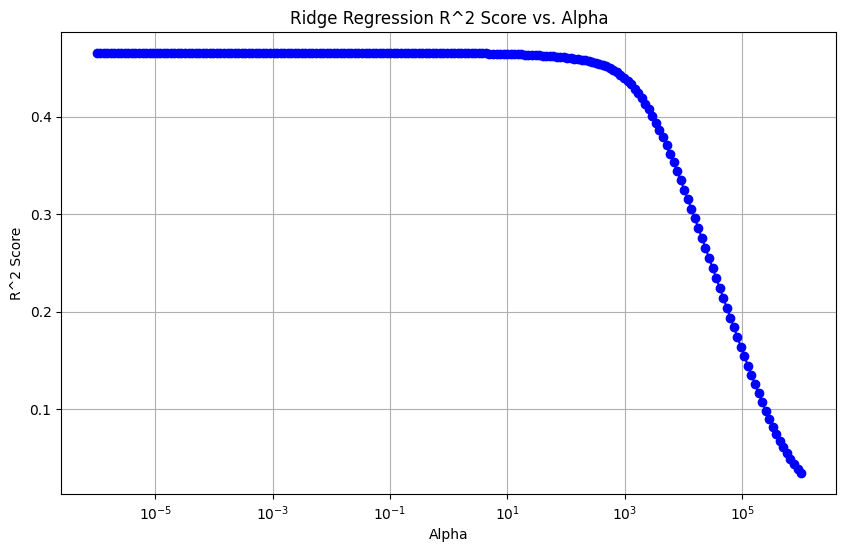

In [80]:
#Set a range of alphas from 10^-6 to 10^6
alphas = np.logspace(-6, 6, 200)
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

r2_scores = []

# Manually compute R^2 scores for each alpha
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    score = ridge.score(X_val_scaled, y_val)
    r2_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_scores, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression R^2 Score vs. Alpha')
plt.grid(True)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 34565030063.46289, tolerance: 2205790490.3694544
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 145008233821.06836, tolerance: 2205790490.3694544
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 221456739670.1172, tolerance: 2205790490.3694544
  model = cd_fast.enet_coor

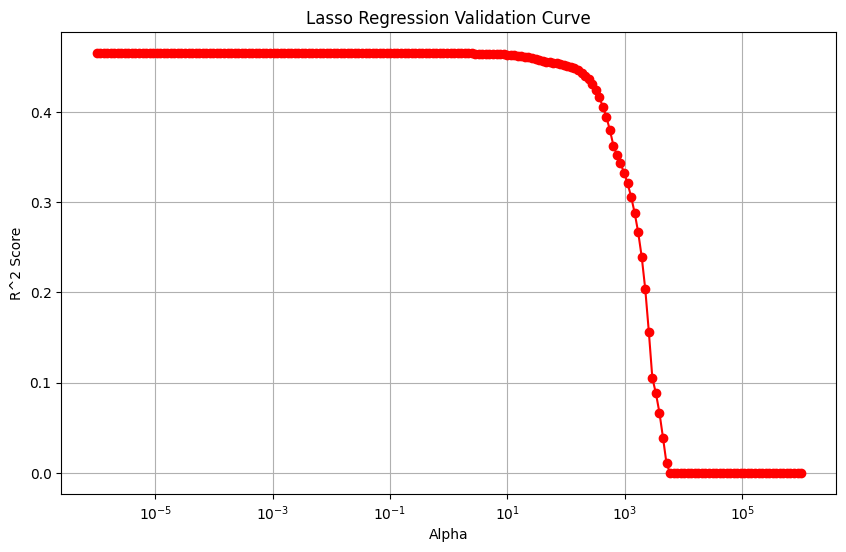

In [81]:
#Set a range of alphas from 10^-6 to 10^6
alphas = np.logspace(-6, 6, 200)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
r2_scores = []

# Manually compute R^2 scores for each alpha
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    score = lasso.score(X_val_scaled, y_val)
    r2_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_scores, marker='o', linestyle='-', color='r')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression Validation Curve')
plt.grid(True)
plt.show()


Selecting an alpha from the leftmost flat portion of the curve should give a model that generalizes the best.

### Lasso model

In [82]:
lasso = Lasso(alpha=0.4, max_iter = 35000)
lasso.fit(X_train_scaled, y_train)

lasso_train_score = lasso.score(X_train_scaled, y_train)
lasso_val_score = lasso.score(X_val_scaled, y_val)

print(f"Training set score: {lasso_train_score}")
print(f"Validation set score: {lasso_val_score}")

Training set score: 0.43991695069715464
Validation set score: 0.465025202400985


### Ridge model

In [83]:
ridge = Ridge(alpha=0.3)
ridge.fit(X_train_scaled, y_train)

ridge_train_score = ridge.score(X_train_scaled, y_train)
ridge_val_score = ridge.score(X_val_scaled, y_val)

print(f"Training set score: {ridge_train_score}")
print(f"Validation set score: {ridge_val_score}")

Training set score: 0.4399249761335551
Validation set score: 0.4650752746956045


All three models have similar both low scores. Indicating an underfitting model, just like the tree models. The data may be nonlinear. To improve score we will apply binning and run the models again.

## Binning

By segmenting a continuous variable into bins, we can capture non-linear relationships more effectively within a linear model. This transformation can simplify the model by turning complex relationships into simpler, segmented interactions within each bin. Essentially help manage non-linear relationships and improve model performance.

In [84]:
numerical_columns = ['Havdybde start', 'Havdybde stopp', 'Startposisjon bredde','Startposisjon lengde','Stopposisjon bredde', 'Stopposisjon lengde', 'Bredde', 'Fartøylengde']
kbd = KBinsDiscretizer(n_bins=20, strategy = 'uniform', encode = 'ordinal', subsample = None)

X_train_binned = X_train_scaled_df.copy()
X_val_binned = X_val_scaled_df.copy()


for col in numerical_columns:
    kbd.fit(X_train_scaled_df[[col]])
    X_train_binned[[col]] = kbd.transform(X_train_scaled_df[[col]]).astype(int)
    X_val_binned[[col]] = kbd.transform(X_val_scaled_df[[col]]).astype(int)



In [85]:
linearregression.fit(X_train_binned, y_train)

binned_linearregression_train_score = linearregression.score(X_train_binned, y_train)
binned_linearregression_val_score = linearregression.score(X_val_binned, y_val)

print("Train Score: ", binned_linearregression_train_score)
print("Validation Score: ", binned_linearregression_val_score)

Train Score:  0.43975941948380115
Validation Score:  0.4634903054857221


In [86]:
lasso.fit(X_train_binned, y_train)

binned_lasso_train_score = lasso.score(X_train_binned, y_train)
binned_lasso_val_score = lasso.score(X_val_binned, y_val)

print("Train score: ", binned_lasso_train_score)
print("Validation score: ", binned_lasso_val_score)

Train score:  0.4397540706226486
Validation score:  0.4634334110313786


In [87]:
ridge.fit(X_train_binned, y_train)

binned_rigde_train_score = ridge.score(X_train_binned, y_train)
binned_ridge_val_score = ridge.score(X_val_binned, y_val)

print("Train score: ", binned_rigde_train_score)
print("Validation score: ", binned_ridge_val_score)

Train score:  0.4397591119762767
Validation score:  0.46346874324734344


The binning hasn't helped with the score. This may indicate that the problem with the model is not related to the linearity of the data. One thing to note is that the validation score is better than training. This can be a sign that the training set has more noise and outliers than the validation set. This could also mean that the model is not complex enough.

<a id="Section4.4"></a>
## Deep learning model
We wish to create a deep learning model using the same dataset as previously. The deep learning model will be trained using the data and by adjusting its internal parameters to minimize the difference between its predictions and the actual outcome. This training process involves calculating a loss function, optimizing the model parameters to reduce this loss, and validating the model's performance using a separate set of test data to ensure it generalizes well to new, unseen data. 

An epoch is a complete pass of the training-dataset through the algorithm. In each epoch there are made predictions, calculated loss, gradients are being computed via backpropagation and the model's weight are being updated by the optimizer. 

In [88]:
class RegressionNet(nn.Module):
    def __init__(self, input_size):
        super(RegressionNet, self).__init__()
        self.layer1 = nn.Linear(input_size, 64) 
        self.layer2 = nn.Linear(64, 1)     

    def forward(self, x):
        # Used ReLU to allow NN to learn nonlinear dependencies, and because of a short runtime
        x = torch.relu(self.layer1(x)) 
        x = self.layer2(x)         
        return x
    
# Converting data to pytorch tensors 
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

#make new datasets with the tensors.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = RegressionNet(X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

epochs = 200
for epoch in range(epochs):
    model.train() 
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()           
        outputs = model(inputs)         
        loss = criterion(outputs, targets) 
        loss.backward()                 
        optimizer.step()                
        train_loss += loss.item() * inputs.size(0) 

    train_loss /= len(train_loader.dataset)
    model.eval()  
    val_loss = 0.0
    with torch.no_grad():  
        for inputs, targets in val_loader:
            outputs = model(inputs)           
            loss = criterion(outputs, targets) 
            val_loss += loss.item() * inputs.size(0)  


    val_loss /= len(val_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}')

Epoch 10: Training Loss = 269955797.6064, Validation Loss = 273658147.1638
Epoch 20: Training Loss = 256985681.3584, Validation Loss = 258874473.0960
Epoch 30: Training Loss = 249905542.8650, Validation Loss = 251906339.5179
Epoch 40: Training Loss = 245747314.8895, Validation Loss = 246864460.4011
Epoch 50: Training Loss = 242898106.3503, Validation Loss = 242914924.6949
Epoch 60: Training Loss = 240739349.6259, Validation Loss = 241782819.1789
Epoch 70: Training Loss = 238716246.8242, Validation Loss = 239842098.9473
Epoch 80: Training Loss = 236660537.4714, Validation Loss = 237114520.3446
Epoch 90: Training Loss = 234852616.4156, Validation Loss = 236348290.2090
Epoch 100: Training Loss = 233073358.0634, Validation Loss = 233846670.5066
Epoch 110: Training Loss = 231471791.9372, Validation Loss = 231626883.4303
Epoch 120: Training Loss = 229783694.3672, Validation Loss = 230597065.7994
Epoch 130: Training Loss = 228272309.6014, Validation Loss = 230872750.7919
Epoch 140: Training L

Both training and validation loss are decreasing for the 200 epochs we are doing. This is sign that the model is learning and improving continously. We stop at 200 epochs since more epochs leads too bigger differences between training and validation. We find the number of epochs where both training and validation loss decrease at the same rate. We tried for different epoch values.

To evalute the deep learning model we create a function to use built-in functions from the torch library. 

In [89]:
def evaluate_model(model, data_loader, dataset_name):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for data, targets in data_loader:
            outputs = model(data)
            predictions.extend(outputs.view(-1).tolist())
            actuals.extend(targets.view(-1).tolist())

    score = r2_score(actuals, predictions)
    print(f"{dataset_name} - Score: {score:.4f}")

evaluate_model(model, train_loader, "Training")
evaluate_model(model, val_loader, "Testing")

Training - Score: 0.6034
Testing - Score: 0.6326


We see a relatively low score, indicating underfitting. Same as in the linear models, test score is higher than training.

<a id="Section4.5"></a>
## Clutstering Model

The dataset contains too many features to make a good clustering model, therefore we will use some of our numeric features in order to get a more understandable model.

In [90]:
features_scaled = X_train_scaled_df[['Havdybde start', 'Havdybde stopp', 'Startposisjon bredde','Startposisjon lengde','Stopposisjon bredde', 'Stopposisjon lengde', 'Bredde', 'Fartøylengde']]

K-Means is a clustering algorithm used to group a dataset into a specified number of clusters. 
We need to find the right K/clusters because it impacts the efficiency and stability of the clustering process, as well as it affect's the model's ability to reveal the data's structure and influences practical decisions.
We will use the elbow method to find the optimal number of centroids/clusters. Choosing K at the point after which the intertia start decreasing in a linear fashion.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/threadpoolctl.py:1186: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


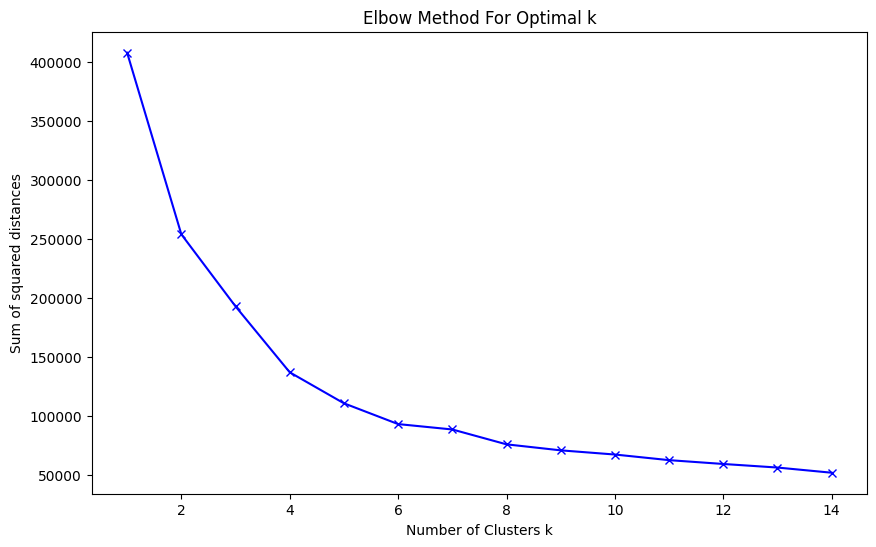

In [91]:
sum_of_squared_distances = []
K = range(1, 15)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km = km.fit(features_scaled)  
    sum_of_squared_distances.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of Clusters k')
plt.ylabel('Sum of squared distances')
plt.title('Elbow Method For Optimal k')
plt.show()

We found from the elbow-method that using 5 clusters should give the best result.

In [92]:
# Applying K-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)  
kmeans.fit(features_scaled)

KMeans(n_clusters=5, random_state=42)

We will use t-SNE because it reduces the number of dimensions in a way that preserves the local structure of the data and allows us to visualize the data.

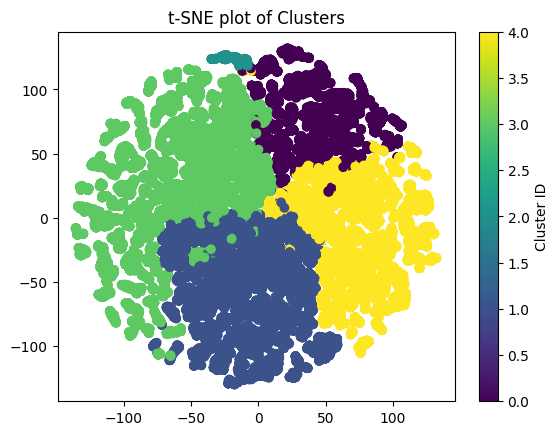

In [93]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(features_scaled)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans.labels_, cmap='viridis')
plt.colorbar(label='Cluster ID')
plt.title('t-SNE plot of Clusters')
plt.show()


We can see 5 clusters, where one is significantly smaller than the others. There is a overlap between many of the clusters which suggest that there is no clear distinction between some of the data points in different clusters.

 In order to get a better understanding we will check for the feature values at cluster centroids.

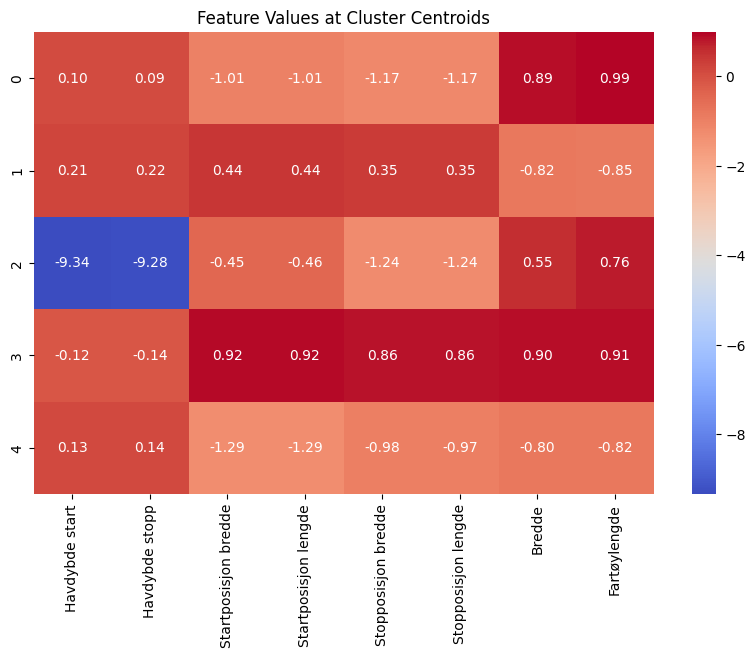

In [94]:
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=features_scaled.columns)

# Plotting the features' centroids for each cluster
plt.figure(figsize=(10, 6))
sns.heatmap(centroid_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Values at Cluster Centroids")
plt.show()


Values close to zero indicate that the features's value from the cluster centriod is close to the mean of that feature for all data points. Positive values indicate that the value is above the mean of that feature across all data points. Reverse for negative values.

Cluster 2 stand out from the rest, with much lower values for 'Havdybde start' and 'Havdybde stopp'. Given the scatterplot from earlier, this cluster might be the very deep sea-depth values. This could be the reason for the cluster being so small. Other than that we find it difficult to get any useful information from clustering.

[Hyperlink til havdybde](#Havdybde)


<a id="Section5"></a>
## Cross-validating

Now we will use cross-validation to ensure that the model is capable of performing well on an independent dataset and not just the data it was trained on. The dataset is divided into 5 equally sized folds. Each fold acts as the testing set 1 time, and acts as the training set 4 times. We will do this procedure on most of the models.

In [95]:
X = pd.concat([X_train, X_val], ignore_index = True)
y = pd.concat([y_train, y_val], ignore_index = True)
kf = KFold(shuffle=True, n_splits = 5)

In [96]:
scoresDTree = cross_val_score(decisiontreeregressor5, X, y, cv=kf)
print("Cross validation for Decision Tree")
print("Scores: {}".format(scoresDTree))
mean = scoresDTree.mean()
std = scoresDTree.std()
print(f"{mean:.2} accuracy with standard deviation of {std:.2}")

Cross validation for Decision Tree
Scores: [0.58423497 0.58850574 0.58642287 0.60620155 0.56899698]
0.59 accuracy with standard deviation of 0.012


In [97]:
scoresRFR = cross_val_score(randomforestregressor, X, y, cv=kf)
print("Cross validation for RandomForestRegressor")
print("Scores: {}".format(scoresRFR))
mean = scoresRFR.mean()
std = scoresRFR.std()
print(f"{mean:.2} accuracy with standard deviation of {std:.2}")

Cross validation for RandomForestRegressor
Scores: [0.62523611 0.59822955 0.61864169 0.62725489 0.61353412]
0.62 accuracy with standard deviation of 0.01


In [102]:
scoresGBR = cross_val_score(gradientboostingregressor1, X, y, cv=kf)
print("Cross validation for GradientBoostingRegressor")
print("Scores: {}".format(scoresGBR))
cross_val_score_gbr = scoresGBR.mean()
std = scoresGBR.std()
print(f"{cross_val_score_gbr:.2} accuracy with standard deviation of {std:.2}")

Cross validation for GradientBoostingRegressor
Scores: [0.6349482  0.66538437 0.65961947 0.65123997 0.63560741]
0.65 accuracy with standard deviation of 0.012


In [99]:
scoresLinReg = cross_val_score(linearregression, X, y, cv=kf)
print("Cross validation for Linear regression")
print("Scores: {}".format(scoresLinReg))
mean = scoresLinReg.mean()
std = scoresLinReg.std()
print(f"{mean:.2} accuracy with standard deviation of {std:.2}")

Cross validation for Linear regression
Scores: [0.44222822 0.44862199 0.45370286 0.44164232 0.44207508]
0.45 accuracy with standard deviation of 0.0048


Based on the initial model validation and cross-validation, GradientBoostingRegressor is the best model. Therefore we will apply it to the test data, to see how it performce on new, unseen data. This will give us an indication on how well the model generalizes. 

## Comparing

In [105]:
test_score = gradientboostingregressor1.score(X_test, y_test)
print(f"Cross validation score: {cross_val_score_gbr:.2}")
print(f"Final score for Gradient Boosting Regressor: {test_score:.2}")

Cross validation score: 0.65
Final score for Gradient Boosting Regressor: 0.64


Still a low score. Performance is similar for unseen data.

<a id="Section6"></a>
# Summary

All our models perform relatively poorly, most of them underfit. Some of the models scored better on validation, this could mean the model is not complex enough, it could also mean that the training set randomly has more noise. We could increase model complexity to learn deeper patterns in the data, the problem with increasing complexity is the risk of overfitting. The model would get too dependent on the training data. We could also reduce the features to remove noise. If parameters like learning rate, number of trees or number of layers in a neural network is tuned incorrectly, it could affect the model's results. Another issue could be the data itself, it may not be any underlying patterns to predict the total 'Rundvekt'. A better approach could be to focus on a specific species or equipment. In hindsight we would probably choose another target value to utilize the data better. We tried various methods to utilize clustering, but found that part to be the most challenging of this project.

This process has been very educational, and we feel like this is a good way to learn different aspects of ML in a more fun and giving way than just reading the theory. The task was maybe a bit too broad, but that also makes us think more independently about what we can do with the data given. All in all happy with the project.



# References

Sarah Guido & Andreas C. Müller. (2017). Introduction to Machine Learning with Python. Sebastopol: O'Reilly Media, Inc.

Machine Learning plus. By Selva Prabhakaran. (May 6 2022). “Top 50 Matplotlib Visualizations - The Master Plots (w/ Full Python Code): ML+.”. Accessed March 5. https://www.machinelearningplus.com/plots/top-50-matplotlib-visualizations-the-master-plots-python/.

GeeksforGeeks. (March 21 2024). “One Hot Encoding in Machine Learning.”. Accessed March 30 https://www.geeksforgeeks.org/ml-one-hot-encoding/.

Mathworks. (2024). "Choosing the Best Machine Learning Classification Model and Avoiding Overfitting" - MATLAB & Simulink. Accessed March 30. https://se.mathworks.com/campaigns/offers/next/choosing-the-best-machine-learning-classification-model-and-avoiding-overfitting.html.

Medium. By Wohlwend Brandon. (July 14 2023). “Three Regression Models for Data Science: Linear Regression, Lasso Regression, and Ridge Regression.” Medium. Accessed April 5. https://medium.com/@brandon93.w/three-regression-models-for-data-science-linear-regression-lasso-regression-and-ridge-regression-6aac73c0d7a5.

GeeksforGeeks. (November 28 2023). “Demonstrating the Different Strategies of KBinsDiscretizer in Scikit Learn.” GeeksforGeeks. Accessed April 7. https://www.geeksforgeeks.org/demonstrating-the-different-strategies-of-kbinsdiscretizer-in-scikit-learn/.

Learnpytorch. (02 2024). PyTorch Neural Network Classification - Zero to Mastery Learn PyTorch for Deep Learning. Accessed April 10. https://www.learnpytorch.io/02_pytorch_classification/.

owardsdatascience, Medium. By Nils Schlüter. (June 5 2019). “Don’t Overfit! - How to Prevent Overfitting in Your Deep Learning Models.” Medium. Accessed April 10. https://towardsdatascience.com/dont-overfit-how-to-prevent-overfitting-in-your-deep-learning-models-63274e552323.

Medium. By Elyse Lee (June 5 2019). “An Intro to Hyper-Parameter Optimization Using Grid Search and Random Search.”. Accessed April 13. https://medium.com/@cjl2fv/an-intro-to-hyper-parameter-optimization-using-grid-search-and-random-search-d73b9834ca0a.

Kaggle. By aussie84. (8 June 2019). “Clustering with KMeans, PCA, TSNE.”. Accessed April 16. https://www.kaggle.com/code/aussie84/clustering-with-kmeans-pca-tsne.

w3schools.(2024). “Machine Learning - Cross Validation.”. Python Machine Learning - Cross Validation. Accessed April 20. https://www.w3schools.com/python/python_ml_cross_validation.asp.

Analytics Vidhya. By Basil Saji. (2024). “Elbow Method for Finding the Optimal Number of Clusters in K-Means.”. Accessed April 24. https://www.analyticsvidhya.com/blog/2021/01/in-depth-intuition-of-k-means-clustering-algorithm-in-machine-learning/.

Team, DataCamp. (March 25 2022). “Lasso and Ridge Regression in Python Tutorial.” DataCamp. DataCamp. Accessed April 26. https://www.datacamp.com/tutorial/tutorial-lasso-ridge-regression?fbclid=IwAR0E9fjyUk74MIu539SpM1f64VnzAAxTfeBTLAZfPFjNWR3gITXoZuNgXdc.